In [1]:
# Loading configuration
%run config.py

<a id="contents"></a>

## Notebook contents

- [**1. Summary of the data**](#intro)
  - [**a. General Info**](#general)
  - [**b. Missingness**](#miss)
- [**2. Data manipulation**](#manip)
  - [**a. Imputation**](#impute)
  - [**b. Normalization**](#norm)
  - [**c. Imbalance**](#imbalance)
- [**3. Visualization**](#visual)
  - [**a. Feature Importance**](#import)
  - [**b. Important Feature Plots**](#ifplots)
  - [**c. Correlation Plots**](#correl)
- [**4. Model Tuning**](#tuning)
  - [**a. Baseline Random Forest**](#baseline-rf)
  - [**b. Baseline Gradient Boost**](#baseline-gb)
  - [**c. Baseline XG Boost**](#baseline-xgb)
  - [**d. PCA Analysis**](#pca)
  - [**d. VIF Analysis**](#vif)
- [**5. Final Model Pipeline**](#final)
  - [**a. Final Random Forest**](#final-rf)
  - [**b. Final Gradient Boost**](#final-gb)
  - [**c. Final XG Boost**](#final-xgb)
- [**6. Final Model Exploration**](#model-expl)
  - [**a. Final Model Build/Accuracy**](#model-expl)
  - [**b. Accuracy Analysis**](#acc)

<a id="intro"></a>
<a id="general"></a>

# 1. Summary of the Data

### **Finalized Research Question:**

*How can multivariate analysis effectively predict the risk of heart disease by identifying and analyzing complex interactions among demographic and clinical risk factors?*


In [2]:
# Read in the data
df = pd.read_csv('heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


### Column Descriptions:

- id (Unique id for each patient)
- age (Age of the patient in years)
- dataset (place of study)
- sex (Male/Female)
- cp chest pain type
    - [typical angina, atypical angina, non-anginal, asymptomatic]
- trestbps resting blood pressure
    - (resting blood pressure (in mm Hg on admission to the hospital))
- chol (serum cholesterol in mg/dl)
- fbs (if fasting blood sugar > 120 mg/dl)
- restecg (resting electrocardiographic results)
    - Values: [normal, stt abnormality, lv hypertrophy]
- thalch: maximum heart rate achieved
- exang: exercise-induced angina (True/ False)
- oldpeak: ST depression induced by exercise relative to rest
- slope: the slope of the peak exercise ST segment 
    - Values: [downsloping, flat, upsloping, nan]
- ca: number of major vessels (0-3) colored by fluoroscopy
- thal: [normal; fixed defect; reversible defect]
- num: the predicted attribute -> categorical heart rate diagnosis

## 📊 Exploratory Data Analysis

I explore the distribution of both continuous and categorical features to understand patterns, detect outliers, and assess relationships with the target variable. I use Histograms and Boxplots for continuous variables like age, trestbps, chol, fbs, thalch, ca. For categorical variables I will use countplots.

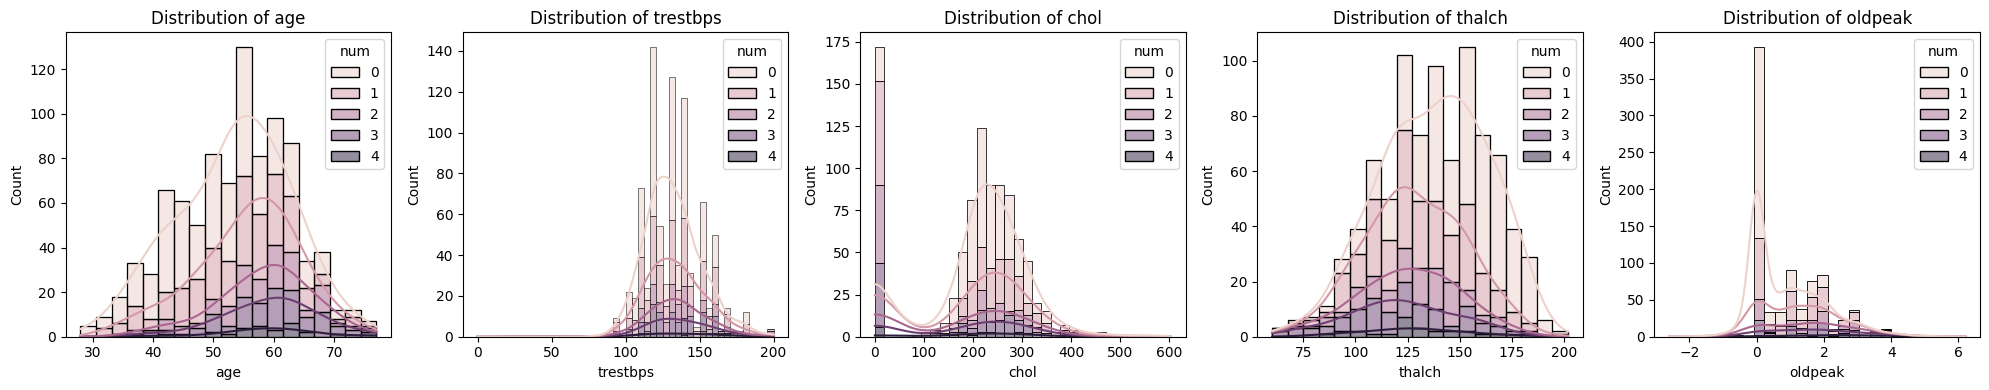

In [5]:
## Histograms
continuous_vars = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

fig, axes = plt.subplots(nrows=1, ncols=len(continuous_vars), figsize=(20, 4))

for i, var in enumerate(continuous_vars):
    sns.histplot(data=df, x=var, hue='num', kde=True, multiple='stack', ax=axes[i])
    axes[i].set_title(f'Distribution of {var}')

plt.tight_layout()


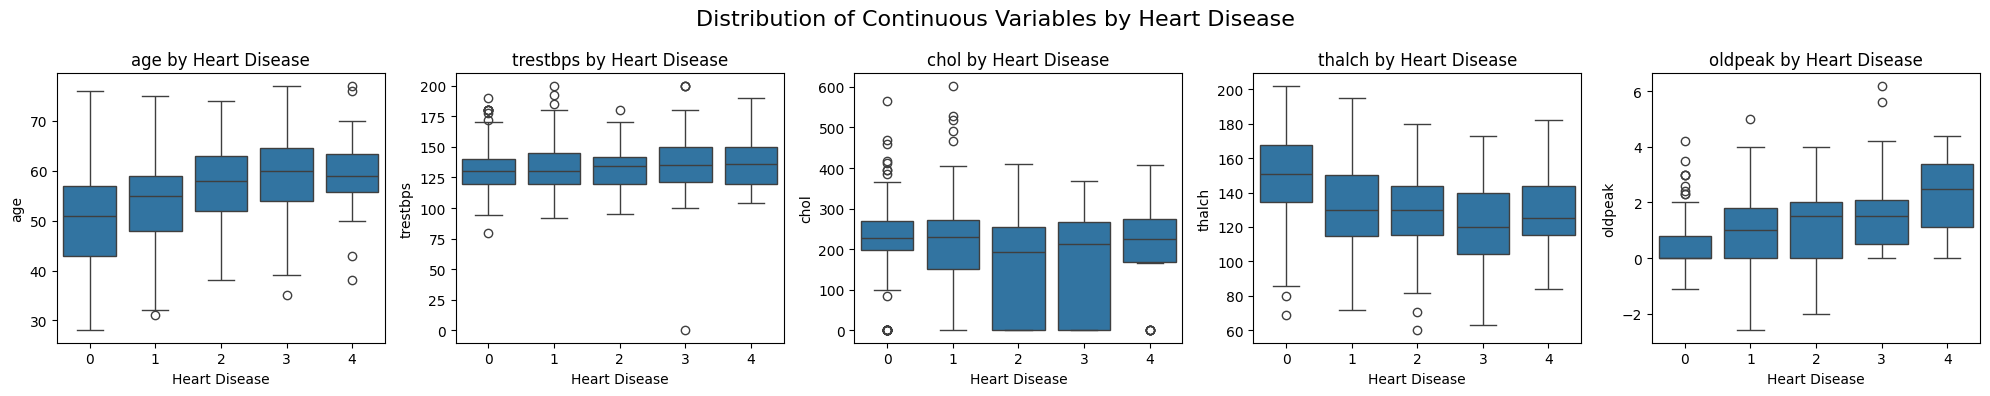

In [7]:
## Boxplots
fig, axes = plt.subplots(nrows=1, ncols=len(continuous_vars), figsize=(20, 4))
for i, var in enumerate(continuous_vars):
    sns.boxplot(data=df, x='num', y=var, ax=axes[i])
    axes[i].set_title(f'{var} by Heart Disease')
    axes[i].set_xlabel('Heart Disease')
    axes[i].set_ylabel(var)

plt.suptitle('Distribution of Continuous Variables by Heart Disease', fontsize=16)
plt.tight_layout()

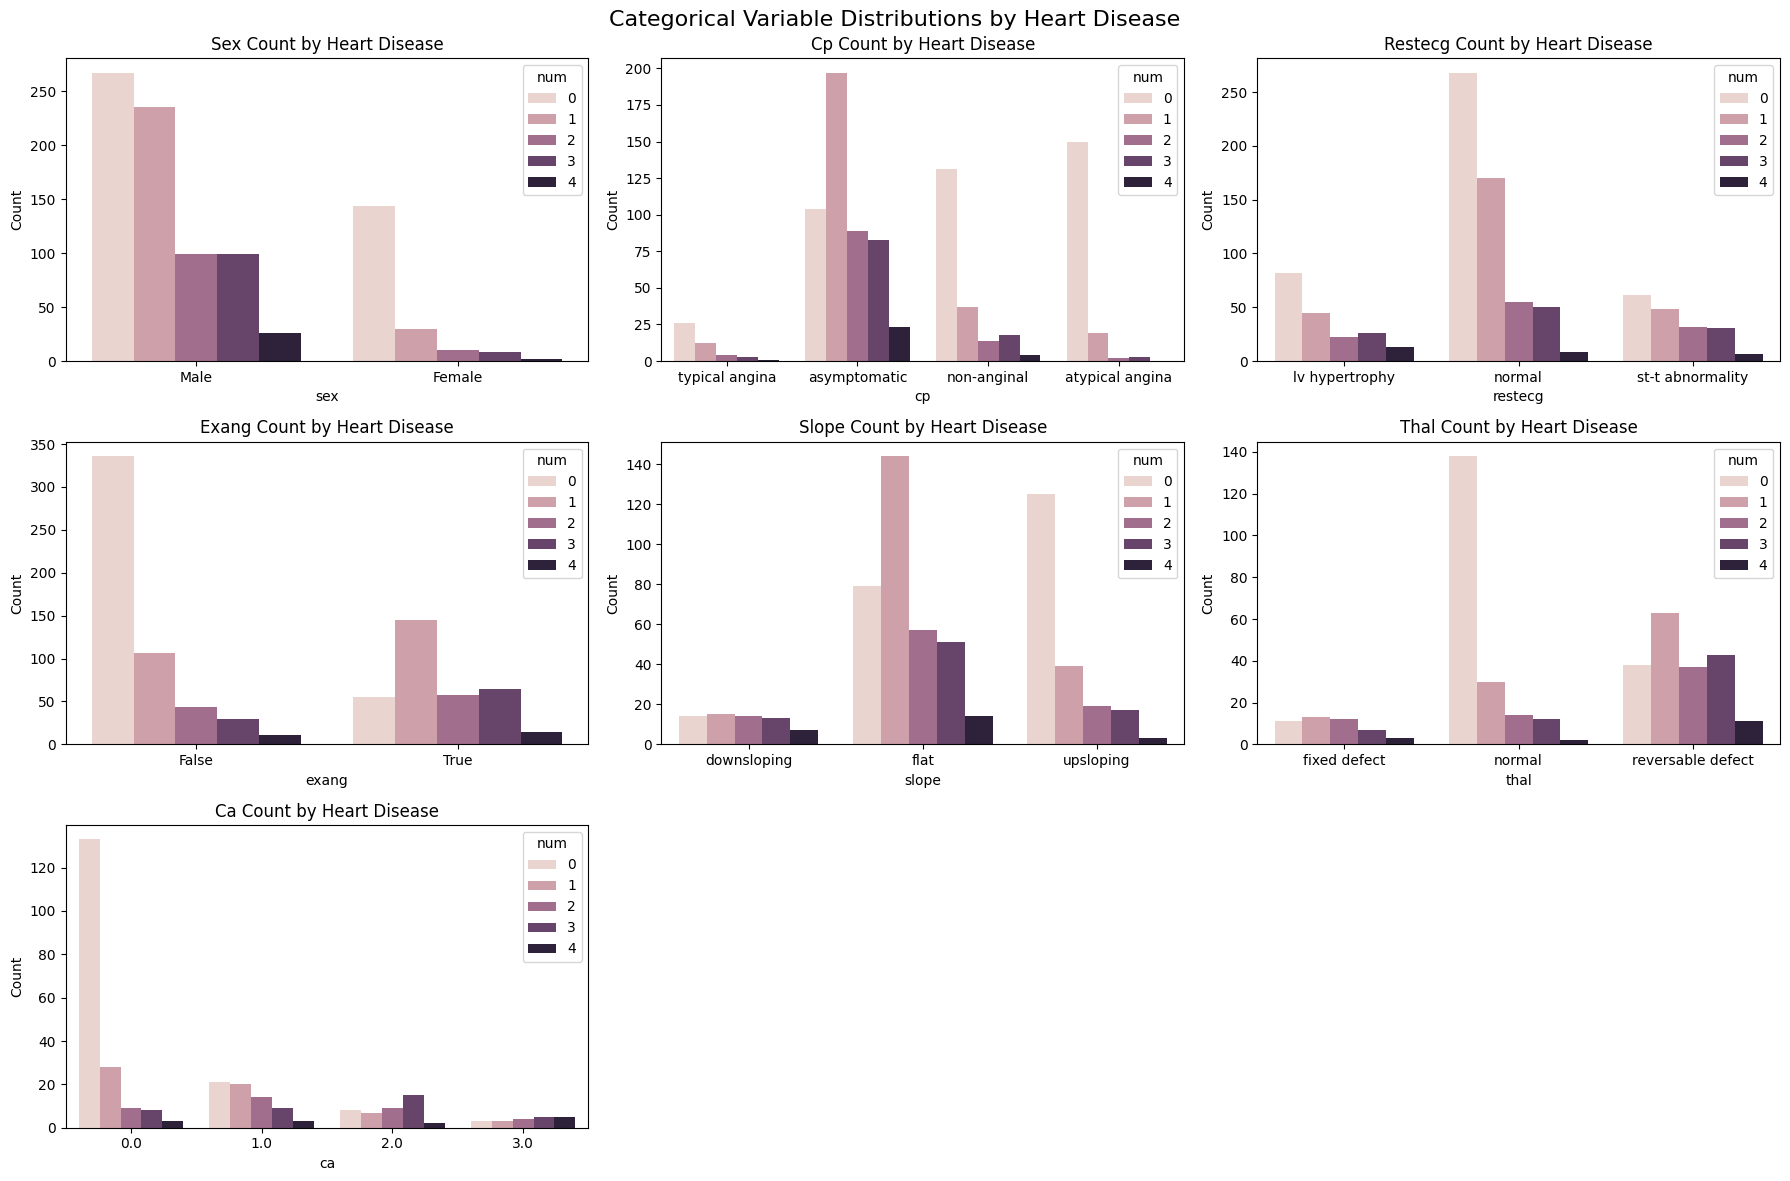

In [9]:
# count plots for cat
categorical_vars = ['sex', 'cp', 'restecg', 'exang', 'slope', 'thal', 'ca']

n_cols = 3
n_rows = int(np.ceil(len(categorical_vars) / n_cols))

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 12))
axes = axes.flatten()

for i, var in enumerate(categorical_vars):
    sns.countplot(data=df, x=var, hue='num', ax=axes[i])
    axes[i].set_title(f'{var.capitalize()} Count by Heart Disease')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Count")

# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Categorical Variable Distributions by Heart Disease', fontsize=16)
plt.tight_layout()


In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None


#### *Learnings from data summary*

From the data visualizations there are a few things that must be dealt with. First and foremost, normalization. Since many of the continuous variables are on a range of values where larger-value variables would bias the models more than small-value ones, we must normalize to equalize effects. Second, is dealing with missingness. Most visible, in Chol distribution plot, we can see many cholesterol values are 0. This is likely just missing values that are assumed to be 0. We must determine how to deal with it so it is not biasing the model. 

<a id="miss"></a>
### **Missingness**

In [224]:
# Display what percentage of the dataset is missing for each column 
missing_percentage = df.isnull().mean() * 100
print(missing_percentage)

id           0.000000
age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
trestbps     6.413043
chol         3.260870
fbs          9.782609
restecg      0.217391
thalch       5.978261
exang        5.978261
oldpeak      6.739130
slope       33.586957
ca          66.413043
thal        52.826087
num          0.000000
dtype: float64


In [225]:
missing_by_sex = df.groupby('sex').apply(lambda x: x.isnull().mean(), include_groups=False)

print("Missigness based on sex:")
print(missing_by_sex)
print()
print('Standard Deviations apart:')
missing_std = df.groupby('sex').apply(lambda x: x.isnull().mean()).std()
print(missing_std)

Missigness based on sex:
         id  age  dataset   cp  trestbps      chol       fbs   restecg  \
sex                                                                      
Female  0.0  0.0      0.0  0.0  0.010309  0.036082  0.056701  0.000000   
Male    0.0  0.0      0.0  0.0  0.078512  0.031680  0.108815  0.002755   

          thalch     exang   oldpeak     slope        ca      thal  num  
sex                                                                      
Female  0.010309  0.010309  0.005155  0.314433  0.500000  0.427835  0.0  
Male    0.073003  0.073003  0.084022  0.341598  0.707989  0.555096  0.0  

Standard Deviations apart:
id          0.000000
age         0.000000
sex         0.000000
dataset     0.000000
cp          0.000000
trestbps    0.048227
chol        0.003113
fbs         0.036850
restecg     0.001948
thalch      0.044331
exang       0.044331
oldpeak     0.055768
slope       0.019208
ca          0.147070
thal        0.089987
num         0.000000
dtype: float64


/var/folders/2j/265z53h12ggd9bsj771vs11w0000gn/T/ipykernel_19634/3922955438.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_std = df.groupby('sex').apply(lambda x: x.isnull().mean()).std()


In [226]:
df['age_percentile'] = pd.qcut(df['age'], 5, labels=False)
missing_by_age = df.groupby('age_percentile').apply(lambda x: x.isnull().mean(), include_groups=False)


print("Missingness based on age:")
print(missing_by_age)

print()
print('Standard Deviations apart:')
missing_std = df.groupby('age_percentile').apply(lambda x: x.isnull().mean()).std()
print(missing_std)

Missingness based on age:
                 id  age  sex  dataset   cp  trestbps      chol       fbs  \
age_percentile                                                              
0               0.0  0.0  0.0      0.0  0.0  0.015306  0.040816  0.086735   
1               0.0  0.0  0.0      0.0  0.0  0.046875  0.052083  0.093750   
2               0.0  0.0  0.0      0.0  0.0  0.054726  0.024876  0.109453   
3               0.0  0.0  0.0      0.0  0.0  0.090909  0.017045  0.119318   
4               0.0  0.0  0.0      0.0  0.0  0.129032  0.025806  0.077419   

                 restecg    thalch     exang   oldpeak     slope        ca  \
age_percentile                                                               
0               0.005102  0.010204  0.010204  0.020408  0.469388  0.688776   
1               0.000000  0.046875  0.046875  0.046875  0.364583  0.703125   
2               0.004975  0.054726  0.054726  0.064677  0.318408  0.691542   
3               0.000000  0.073864  0.073864

/var/folders/2j/265z53h12ggd9bsj771vs11w0000gn/T/ipykernel_19634/2667882367.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_std = df.groupby('age_percentile').apply(lambda x: x.isnull().mean()).std()


In [227]:
missing_by_output = df.groupby('num').apply(lambda x: x.drop('age_percentile', axis=1).isnull().mean(), include_groups=False)

print("Check if missingness is correlated to response variable:")
print(missing_by_output)

print()
print('Standard Deviations apart:')
missing_std = df.groupby('num').apply(lambda x: x.isnull().mean()).std()
print(missing_std)

Check if missingness is correlated to response variable:
      id  age  sex  dataset   cp  trestbps      chol       fbs   restecg  \
num                                                                        
0    0.0  0.0  0.0      0.0  0.0  0.048662  0.046229  0.034063  0.000000   
1    0.0  0.0  0.0      0.0  0.0  0.049057  0.026415  0.150943  0.007547   
2    0.0  0.0  0.0      0.0  0.0  0.073394  0.018349  0.192661  0.000000   
3    0.0  0.0  0.0      0.0  0.0  0.140187  0.009346  0.121495  0.000000   
4    0.0  0.0  0.0      0.0  0.0  0.107143  0.035714  0.071429  0.000000   

       thalch     exang   oldpeak     slope        ca      thal  
num                                                              
0    0.048662  0.048662  0.051095  0.469586  0.598540  0.545012  
1    0.049057  0.049057  0.056604  0.252830  0.781132  0.600000  
2    0.064220  0.064220  0.073394  0.174312  0.669725  0.422018  
3    0.121495  0.121495  0.149533  0.242991  0.654206  0.420561  
4    0.071429 

/var/folders/2j/265z53h12ggd9bsj771vs11w0000gn/T/ipykernel_19634/247419566.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_std = df.groupby('num').apply(lambda x: x.isnull().mean()).std()


<a id="dataset"></a>

In [228]:
missing_by_loc = df.groupby('dataset').apply(lambda x: x.drop('age_percentile', axis=1).isnull().mean(), include_groups=False)
print(df.groupby('dataset').count())

print()
print("Check if missingness is correlated to the dataset variable:")
print(missing_by_loc)

print()
print('Standard Deviations apart:')
missing_std = df.groupby('dataset').apply(lambda x: x.isnull().mean()).std()
print(missing_std)

                id  age  sex   cp  trestbps  chol  fbs  restecg  thalch  \
dataset                                                                   
Cleveland      304  304  304  304       304   304  304      304     304   
Hungary        293  293  293  293       292   270  285      292     292   
Switzerland    123  123  123  123       121   123   48      122     122   
VA Long Beach  200  200  200  200       144   193  193      200     147   

               exang  oldpeak  slope   ca  thal  num  age_percentile  
dataset                                                               
Cleveland        304      304    303  299   301  304             304  
Hungary          292      293    104    3    28  293             293  
Switzerland      122      117    106    5    71  123             123  
VA Long Beach    147      144     98    2    34  200             200  

Check if missingness is correlated to the dataset variable:
                id  age  sex   cp  trestbps      chol       fb

/var/folders/2j/265z53h12ggd9bsj771vs11w0000gn/T/ipykernel_19634/1079559701.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_std = df.groupby('dataset').apply(lambda x: x.isnull().mean()).std()


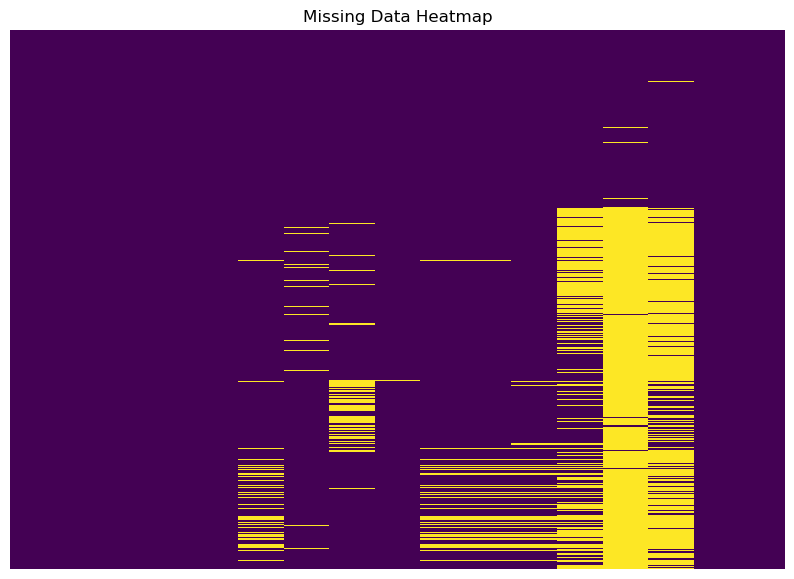

In [229]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', cbar_kws={'label': 'Missingness'}, xticklabels=False, yticklabels=False)
plt.title("Missing Data Heatmap")
plt.show()

#### *Learnings from missingness investigation*

From the missingness investigation, we learn a few things. 

1) **High Missing-Rate Variables:** The first major takeaway is the high levels of missingness of a few of the predictor values. There are many different ways to deal with missingness, but it is general practice to think about dropping the predictor if there is insufficient information. In this case, 2 or 3 variables jump out. 'ca', 'thal' and 'slope' are missing 66%, 52%, and 34%, respectively, of these values. 'ca' and 'thal' then seem pretty clear to be dropped as, there is not sufficient datapoints for valid imputation, especially since the missingness is heavily based on which [dataset](#dataset) it came from. Cleveland was the dominant source and of this variable, so to impute means of 'ca' as a solution to the missingness would be to bias the data towards the 'ca' values coming from Cleveland. As such, we will drop 'ca' and 'thal' from the dataframe for future usage. With regards to the 'slope' variable we decided to keep it because it is generally pretty evenly across the datasets, so to impute a mean would reasonably be representative of the all the datasets' datapoints. 

2) **Sex based missingness:** Investigating the missingness based on sex, the dataset seems valid in most regards. The discrepancy across the sexes is minimal with regards to the standard deviation across all variables and so we are satisfied with that.

3) **Age based missingness:** Missingness based on age seems respectable as well. All deviations across age demographics seem within respectable ranges. 

4) **Response variable based missingness:** Although, the standard deviations for missingness across the 5 categorization groups for the response variable are generally good, there is a slight elevation in missingness variance for 'slope' variable (0.12 SDs). This does not stand out as that alarming, because it appears that variance stems mostly from the 0-group (i.e. lowest ranked heart problem group). This is likely becuase doctors do not take that measurement on the people who generally have otherwise healthy indicators. As we progress through our analysis, this is something that must be kept in mind, as it likely will bias the dataset such that people of the 0-group go under represented with respect to the slope variable. As such, if we are to rely on the slope variable to predict into the 0-group, it will likely be somewhat ineffective. 

5) **Dataset based missingness:** As we know, this large dataset is made up of 4 different smaller datasets. The missingness based on where a datapoint came from is the most significant factor for missingness. A lot of the variables have higher rates of missingness depending on which dataset a datapoint came from. For example, nearly all of the Cleveland dataset has the 'ca' variable measurement, but nearly none of the other 3 datasets do. It is hard to predict what affect all this missingess will have on the dataset, but it will be an important factor to keep in mind during futher analysis.

<a id="manip"></a>
# 2. Data Manipulation/Processing

In [230]:
# Remove columns 'ca' and 'thal'

df = df.drop(['ca', 'thal'], axis=1)

# Remove columns 'dataset' and 'id' for reason mentioned below
df = df.drop(['dataset', 'id'], axis =1)

<div style = "background: light grey; border: thin solid black; border-radius: 2px; padding: 5px">

**Note: I do not want to be biased by the 'dataset' variable as it represents nothing beyond which location the dataset came from**

Furthermore, it is unrealistic to expect to extrapolate conclusions of heart disease risk factor based on location that data is gathered. I do not suspect that there was enough precision in datacollection to be able to have representative demographics in the different locations so that it accurately represents location as a possible predictor. As such I drop that predictor above.

**Note: I am also dropping the 'id' variable as it serves no purpose in data analysis**
</div>

<a id="impute"></a>
### **Imputation**

<div style = "background: light grey; border: thin solid black; border-radius: 2px; padding: 5px">

**Note: I am treating 'chol' differently because it has a large number of 0 values which does not make sense.**

We are assuming that this is a representation of null values, and as such, before imputation are replacing 0s with nan.
</div>

In [231]:
# dealing with chol 
df['chol'] = df['chol'].replace(0, np.nan)

missing_percentage = df.isnull().mean() * 100
print(missing_percentage)

# Separate categorical and numerical features
categorical_features = df.select_dtypes(include=['object']).columns
numerical_features = df.select_dtypes(include=['number']).columns

# Initialize OneHotEncoder for categorical features with sparse=False to get a dense array
one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Apply one-hot encoding to **all** categorical features
data_encoded_categorical = one_hot_encoder.fit_transform(df[categorical_features])

# Create a DataFrame for the encoded categorical features
encoded_columns = one_hot_encoder.get_feature_names_out(categorical_features)
df_encoded_categorical = pd.DataFrame(data_encoded_categorical, columns=encoded_columns)

# First DataFrame: Include numerical features, categorical variables, and the one-hot encoded features
df_full = pd.concat([df[numerical_features].reset_index(drop=True), df[categorical_features].reset_index(drop=True), df_encoded_categorical], axis=1)

# Second DataFrame: Include numerical features and the encoded categorical features only
df_encoded = pd.concat([df[numerical_features].reset_index(drop=True), df_encoded_categorical], axis=1)

print("\nSecond Dataframe (Numerical and Encoded Categorical Only):")
print(df_encoded.info())

print("\nDataframe Information (for both dataframes):")
print(df_full.info())

age                0.000000
sex                0.000000
cp                 0.000000
trestbps           6.413043
chol              21.956522
fbs                9.782609
restecg            0.217391
thalch             5.978261
exang              5.978261
oldpeak            6.739130
slope             33.586957
num                0.000000
age_percentile     0.000000
dtype: float64

Second Dataframe (Numerical and Encoded Categorical Only):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       920 non-null    int64  
 1   trestbps                  861 non-null    float64
 2   chol                      718 non-null    float64
 3   thalch                    865 non-null    float64
 4   oldpeak                   858 non-null    float64
 5   num                       920 non-null    int64  
 6   age_percent

In [232]:
# Continuous variables

# determining optimal neighbors numbers
neighbors_range = range(1, 11)
optimal_neighbors = {}

missing_features = df_full.columns[df_full.isnull().any()].tolist()

for feature in missing_features:
    print(f"Finding optimal n_neighbors for feature '{feature}'...")
    # Check if the feature is categorical
    if df_full[feature].dtype == 'object':
        print(f"Feature '{feature}' is categorical. Skipping imputation.")
        continue
    
    # Convert all columns to float to handle NaN assignments
    df_encoded = df_encoded.astype(float)
    
    # Split the data into training (non-missing) and testing (simulate missingness)
    data_complete = df_encoded[df_encoded[feature].notnull()]
    X_train, X_test = train_test_split(data_complete, test_size=0.2, random_state=42)

    # Track errors for each n_neighbors
    errors = []
    
    for n in neighbors_range:
        # Initialize KNN Imputer with n_neighbors
        imputer = KNNImputer(n_neighbors=n)
        
        # Impute only the target feature
        X_train_feature = X_train.copy()
        X_test_feature = X_test.copy()
        
        # Explicitly cast columns to float before setting them to NaN
        X_train_feature.loc[:, X_train_feature.columns != feature] = X_train_feature.loc[:, X_train_feature.columns != feature].astype(float)
        X_test_feature.loc[:, X_test_feature.columns != feature] = X_test_feature.loc[:, X_test_feature.columns != feature].astype(float)
        
        # Set all other columns except the target feature to NaN to isolate the imputation
        X_train_feature.loc[:, X_train_feature.columns != feature] = np.nan
        X_test_feature.loc[:, X_test_feature.columns != feature] = np.nan
        
        # Apply imputation
        X_train_imputed = imputer.fit_transform(X_train_feature)
        X_test_imputed = imputer.transform(X_test_feature)
        
        # Extract the imputed values for the feature
        imputed_train_df = pd.DataFrame(X_train_imputed, columns=[feature])
        imputed_test_df = pd.DataFrame(X_test_imputed, columns=[feature])
        
        # Compute Mean Squared Error between true and imputed values for the feature
        true_values = X_test[feature].values  # true values in the test set
        mse = mean_squared_error(true_values, imputed_test_df[feature].values)
        errors.append(mse)

    # Select the n_neighbors with the lowest error
    optimal_neighbors[feature] = neighbors_range[np.argmin(errors)]

# Display the optimal n_neighbors for each feature
print(optimal_neighbors)

# for full dataframe with categorical variables (will have nans)
df_imputed_full = df_full.copy()

# for encoded dataframe
df_imputed = df_encoded.copy()

# Do it to full dataframe (categorical variables included)
for feature, optimal_n in optimal_neighbors.items():
    print(f"Imputing feature '{feature}' with n_neighbors={optimal_n}...")

    imputer = KNNImputer(n_neighbors=optimal_n)
    imputed_feature = imputer.fit_transform(df_imputed_full[[feature]])

    df_imputed_full[[feature]] = imputed_feature

# Do it to partial dataframe (just encoded dataframe)
for feature, optimal_n in optimal_neighbors.items():
    print(f"Imputing feature '{feature}' with n_neighbors={optimal_n}...")

    imputer = KNNImputer(n_neighbors=optimal_n)
    imputed_feature = imputer.fit_transform(df_imputed[[feature]])

    df_imputed[[feature]] = imputed_feature

# Ensure that there is no missingness in the dataframe
missing_percentage = df_imputed.isnull().mean() * 100
print("Percentage of missingness for each column in the dataframe:")
print(missing_percentage)

Finding optimal n_neighbors for feature 'trestbps'...
Finding optimal n_neighbors for feature 'chol'...
Finding optimal n_neighbors for feature 'thalch'...
Finding optimal n_neighbors for feature 'oldpeak'...
Finding optimal n_neighbors for feature 'fbs'...
Feature 'fbs' is categorical. Skipping imputation.
Finding optimal n_neighbors for feature 'restecg'...
Feature 'restecg' is categorical. Skipping imputation.
Finding optimal n_neighbors for feature 'exang'...
Feature 'exang' is categorical. Skipping imputation.
Finding optimal n_neighbors for feature 'slope'...
Feature 'slope' is categorical. Skipping imputation.
{'trestbps': 1, 'chol': 1, 'thalch': 1, 'oldpeak': 1}
Imputing feature 'trestbps' with n_neighbors=1...
Imputing feature 'chol' with n_neighbors=1...
Imputing feature 'thalch' with n_neighbors=1...
Imputing feature 'oldpeak' with n_neighbors=1...
Imputing feature 'trestbps' with n_neighbors=1...
Imputing feature 'chol' with n_neighbors=1...
Imputing feature 'thalch' with n

<a id="norm"></a>
### **Normalization**

<div style = "background: light grey; border: thin solid black; border-radius: 2px; padding: 5px">

**Note: I am also initializing a dataframe that normalizes the numerical variables of 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca'**

This will allow us to have access to both dataframes and investigate the value that normalization will provide
</div>

In [233]:
# Find numeric values
print(df_imputed_full.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       920 non-null    int64  
 1   trestbps                  920 non-null    float64
 2   chol                      920 non-null    float64
 3   thalch                    920 non-null    float64
 4   oldpeak                   920 non-null    float64
 5   num                       920 non-null    int64  
 6   age_percentile            920 non-null    int64  
 7   sex                       920 non-null    object 
 8   cp                        920 non-null    object 
 9   fbs                       830 non-null    object 
 10  restecg                   918 non-null    object 
 11  exang                     865 non-null    object 
 12  slope                     611 non-null    object 
 13  sex_Female                920 non-null    float64
 14  sex_Male  

In [234]:
# Initialize scaler for normalizing
scaler = StandardScaler()

#normalizable columns (leave out id as it is not a predictor)
norm_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

# Normalize only the selected columns
df_norm_values = scaler.fit_transform(df_imputed[norm_cols])
df_norm_num = pd.DataFrame(df_norm_values, columns=norm_cols)

# Combine the normalized columns with the non-normalized columns
# For just encoded dataframe
df_final_imp = df_imputed.copy()
df_final_imp[norm_cols] = df_norm_num

# For full dataframe
df_final_full = df_imputed_full.copy()
df_final_full[norm_cols] = df_norm_num

<a id ='imbalance'></a>
### **Imbalance**

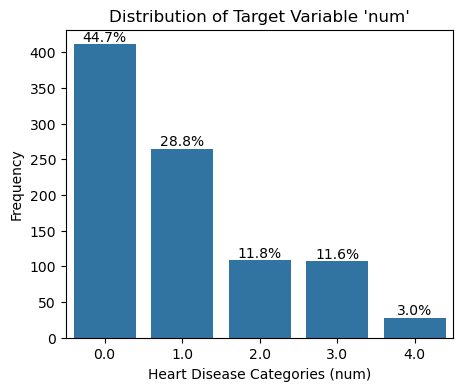

In [235]:
# check for imbalance in response variable

plt.figure(figsize=(5, 4))
sns.countplot(data=df_final_imp, x='num')

# Calculate percentages
total = len(df_final_imp) 
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'  
    plt.text(p.get_x() + p.get_width() / 2,  
             p.get_height(),  
             percentage, 
             ha='center', va='bottom')

plt.title("Distribution of Target Variable 'num'")
plt.xlabel("Heart Disease Categories (num)")
plt.ylabel("Frequency")
plt.show()

From the quick investigation above, we can see that there is significant imbalance in our dataset. Group 0 in the response variable makes up a large portion of the dataset. As such, we must do something to adjust for this, because otherwise a model that simply says group 0 will automatically have 44.7% accuracy. Although, this is poor accuracy, if there is another model that never predicts group 4, it can get up to 97% accuracy. Furthermore, if we build a model on the data as is, we bias the model to underpredict the higher heart disease-risk groups. We want a model that is capable of predicting the higher categories (maybe even emphasize those categories) because that is where it is important to be able to predict heart disease based on risk factors, as opposed to recognize when there is limited risk.

**Method:**
It would not make sense to do undersampling, because we would be required to stoop down to the lowest group frequency, which is group 4 (3%). This would leave us with a pretty small dataset. As such, we will do SMOTE oversampling. We will also limit this to a training dataset as to limit the correlation between the training and test sets. If we were to do it to entire dataset, many points in the test set would be correlated to the training data, and thus the model would be related to those datapoints already. The correlation would result from SMOTE creating synthetic points in training set that overlap with the test set. Doing SMOTE sampling only to training data preserves the independence of the test set. This means the model will be evaluated on how well it generalizes to real, unaltered data.

In [236]:
from imblearn.over_sampling import SMOTE
# Separate features (X) and target (y)
X = df_final_imp.drop(columns=['num'])
y = df_final_imp['num']

# Split into train and test sets to apply SMOTE only on the training data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize SMOTE with specific settings (optional: k_neighbors for SMOTE parameter tuning)
smote = SMOTE(random_state=42)

# Apply SMOTE only to the training data
X_train, y_train = smote.fit_resample(X_train, y_train)

# Check the distribution of the resampled target classes
print("Original target class distribution:")
print(y_train.value_counts(normalize=True))
print("\nSMOTE-resampled target class distribution:")
print(y_train.value_counts(normalize=True))

df_model_final = pd.concat([X_train, y_train.reset_index(drop=True)], axis=1)


Original target class distribution:
num
3.0    0.2
0.0    0.2
2.0    0.2
1.0    0.2
4.0    0.2
Name: proportion, dtype: float64

SMOTE-resampled target class distribution:
num
3.0    0.2
0.0    0.2
2.0    0.2
1.0    0.2
4.0    0.2
Name: proportion, dtype: float64


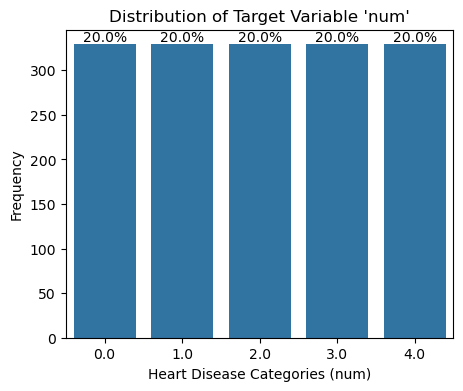

In [237]:
# Check imputation worked

plt.figure(figsize=(5, 4))
sns.countplot(data=df_model_final, x='num')

# Calculate percentages
total = len(df_model_final) 
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'  
    plt.text(p.get_x() + p.get_width() / 2,  
             p.get_height(),  
             percentage, 
             ha='center', va='bottom')

plt.title("Distribution of Target Variable 'num'")
plt.xlabel("Heart Disease Categories (num)")
plt.ylabel("Frequency")
plt.show()

<a id="visual"></a>
# 3. Visualizations

Note that these visualizations will simply be on the test data

They also will be using the data without dealing with imbalance, because otherwise it will be more difficult to recognize trends across the three groups. 

In [238]:
# Now I want to display the summary statistics of the all of the variables. 
# Modify this list based on your dataset
categorical_vars = ['sex', 'cp', 'restecg', 'slope', 'num']  # example categorical variables
numeric_vars = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']  # example continuous variables

# Display summary statistics for continuous variables in original DataFrame
print("Summary statistics for regression variables in original DataFrame (df):")
print(df[numeric_vars].describe().drop(['25%', '50%', '75%']))

# Display summary statistics for continuous variables in processed DataFrame
print("\nSummary statistics for regression variables in finished DataFrame (df_final_full):")
print(df_final_full[numeric_vars].describe())

# Display summary statistics for categorical variables in processed DataFrame
print("\nSummary statistics for categorical variables in finished DataFrame with imputation (df_final_full):")
cat_summary = pd.DataFrame({
    'Mode': df_final_full[categorical_vars].mode().iloc[0],
    'Mode Count': [df_final_full[col].value_counts().iloc[0] for col in categorical_vars],
    'Unique Values': df_final_full[categorical_vars].nunique(),
    'Categories': [df_final_full[col].unique() for col in categorical_vars]
})
print(cat_summary)

Summary statistics for regression variables in original DataFrame (df):
              age    trestbps        chol      thalch     oldpeak
count  920.000000  861.000000  718.000000  865.000000  858.000000
mean    53.510870  132.132404  246.832869  137.545665    0.878788
std      9.424685   19.066070   58.527062   25.926276    1.091226
min     28.000000    0.000000   85.000000   60.000000   -2.600000
max     77.000000  200.000000  603.000000  202.000000    6.200000

Summary statistics for regression variables in finished DataFrame (df_final_full):
                age      trestbps          chol        thalch       oldpeak
count  9.200000e+02  9.200000e+02  9.200000e+02  9.200000e+02  9.200000e+02
mean   6.178632e-17 -6.873729e-16  1.158494e-17  2.162521e-16 -4.633974e-17
std    1.000544e+00  1.000544e+00  1.000544e+00  1.000544e+00  1.000544e+00
min   -2.708286e+00 -7.167915e+00 -3.132163e+00 -3.086416e+00 -3.303061e+00
25%   -6.912073e-01 -6.581583e-01 -5.628788e-01 -6.983397e-01 -8.343

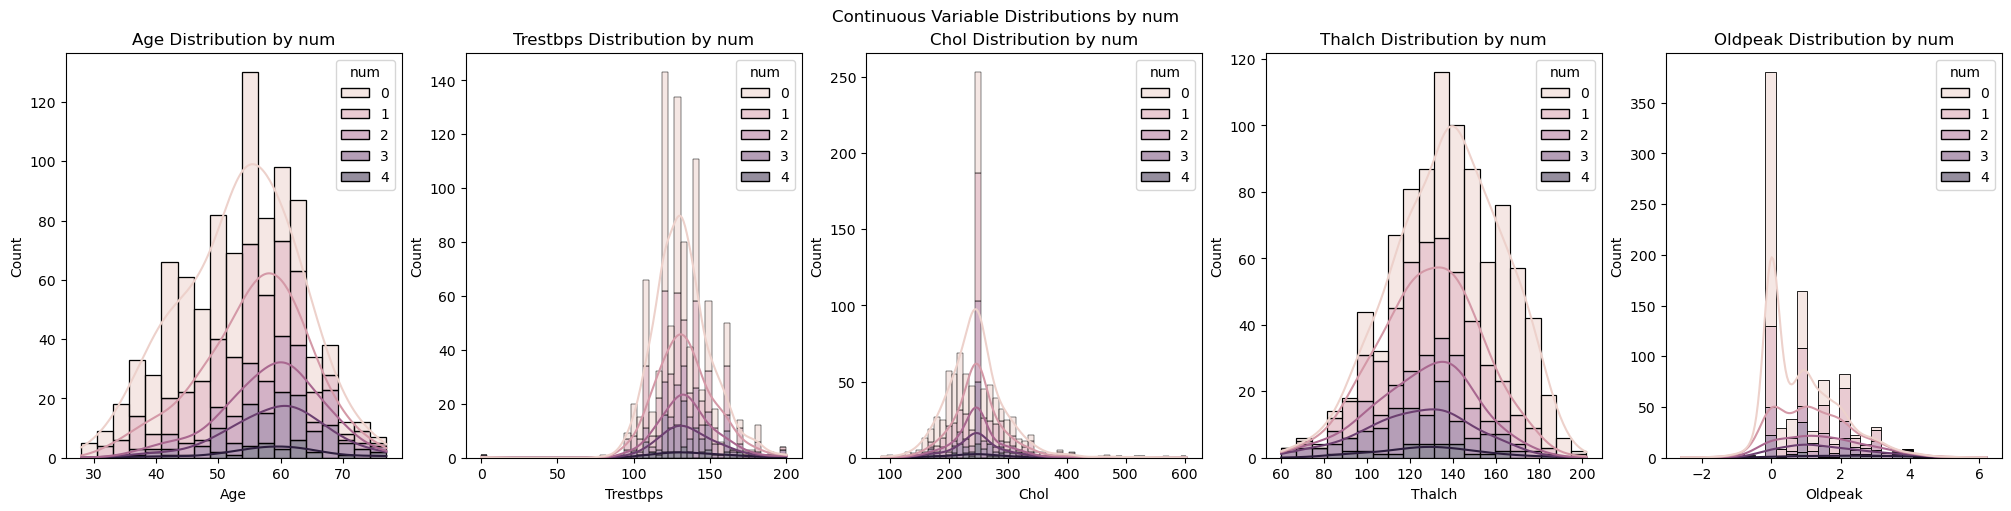

In [239]:
# Histograms (before normalization because then the values make sense)

continuous_vars = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

fig, axes = plt.subplots(nrows=1, ncols=len(continuous_vars), figsize=(20, 5), constrained_layout=True)

for i, var in enumerate(continuous_vars):
    sns.histplot(data=df_imputed_full, x=var, hue='num', kde=True, multiple='stack', ax=axes[i])
    axes[i].set_title(f'{var.capitalize()} Distribution by num')
    axes[i].set_xlabel(var.capitalize())
    axes[i].set_ylabel('Count')

plt.suptitle('Continuous Variable Distributions by num')
plt.show()

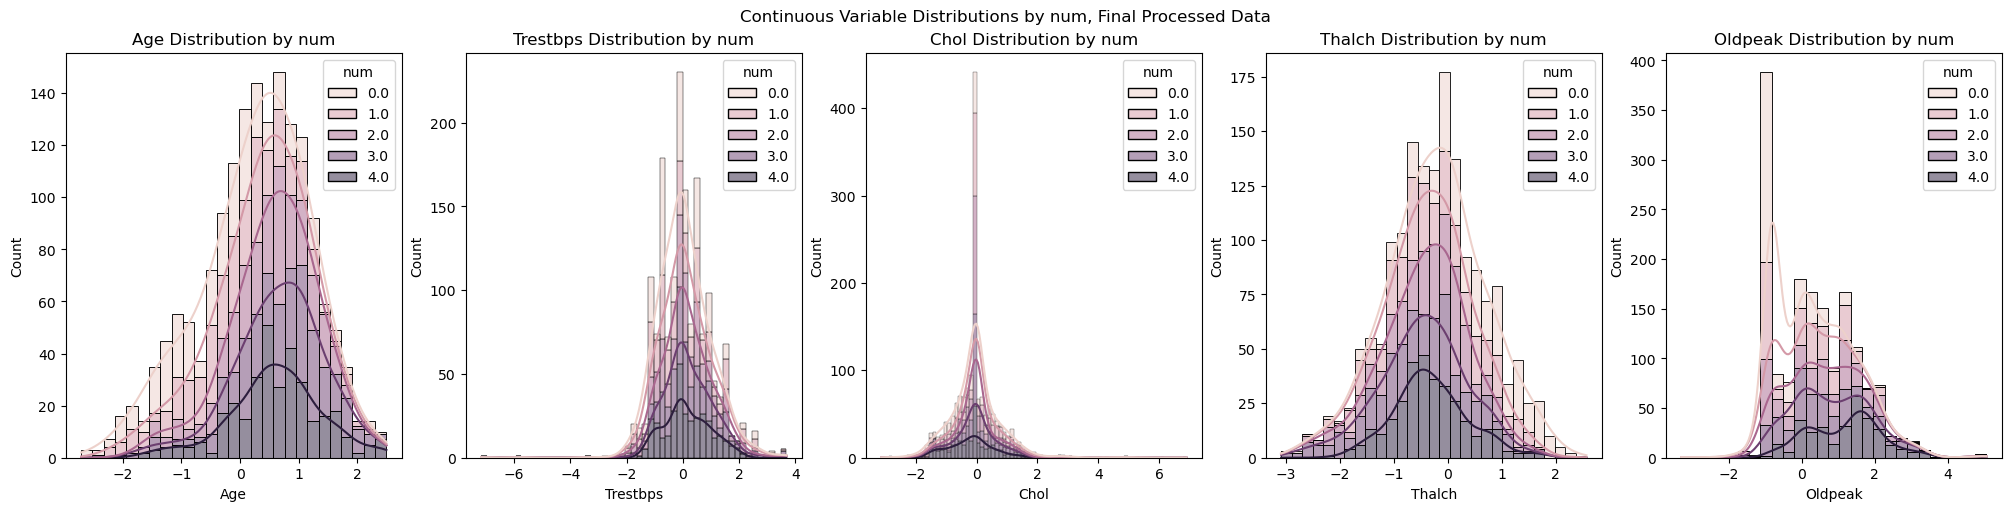

In [240]:
# Histograms on FINAL PROCESSED DATASET

continuous_vars = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

fig, axes = plt.subplots(nrows=1, ncols=len(continuous_vars), figsize=(20, 5), constrained_layout=True)

for i, var in enumerate(continuous_vars):
    sns.histplot(data=df_model_final, x=var, hue='num', kde=True, multiple='stack', ax=axes[i])
    axes[i].set_title(f'{var.capitalize()} Distribution by num')
    axes[i].set_xlabel(var.capitalize())
    axes[i].set_ylabel('Count')

plt.suptitle('Continuous Variable Distributions by num, Final Processed Data')
plt.show()

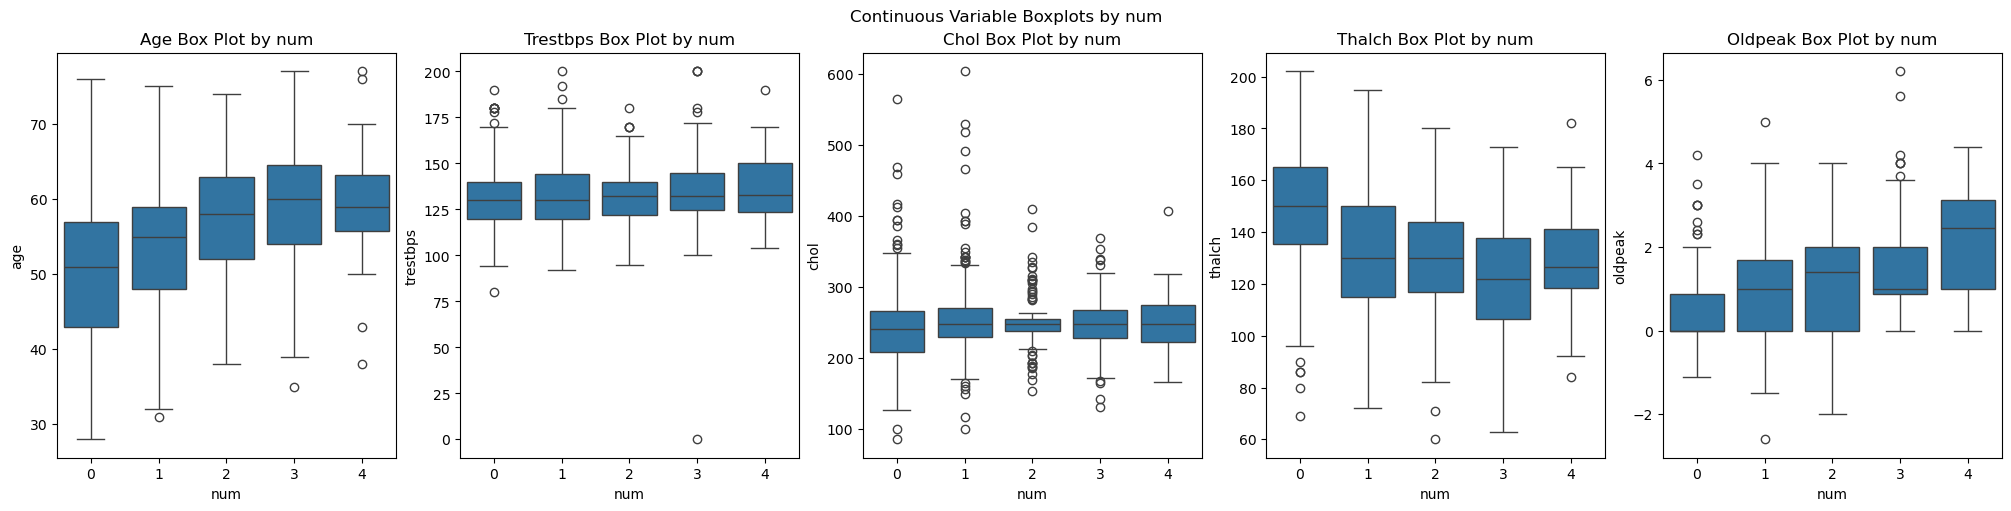

In [241]:
# Boxplots  (before normalization because then the values make sense)
fig, axes = plt.subplots(nrows=1, ncols=len(continuous_vars), figsize=(20, 5), constrained_layout=True)
for i, var in enumerate(continuous_vars):
    sns.boxplot(data=df_imputed_full, x='num', y=var, ax = axes[i])
    axes[i].set_title(f'{var.capitalize()} Box Plot by num')

plt.suptitle('Continuous Variable Boxplots by num')
plt.show()

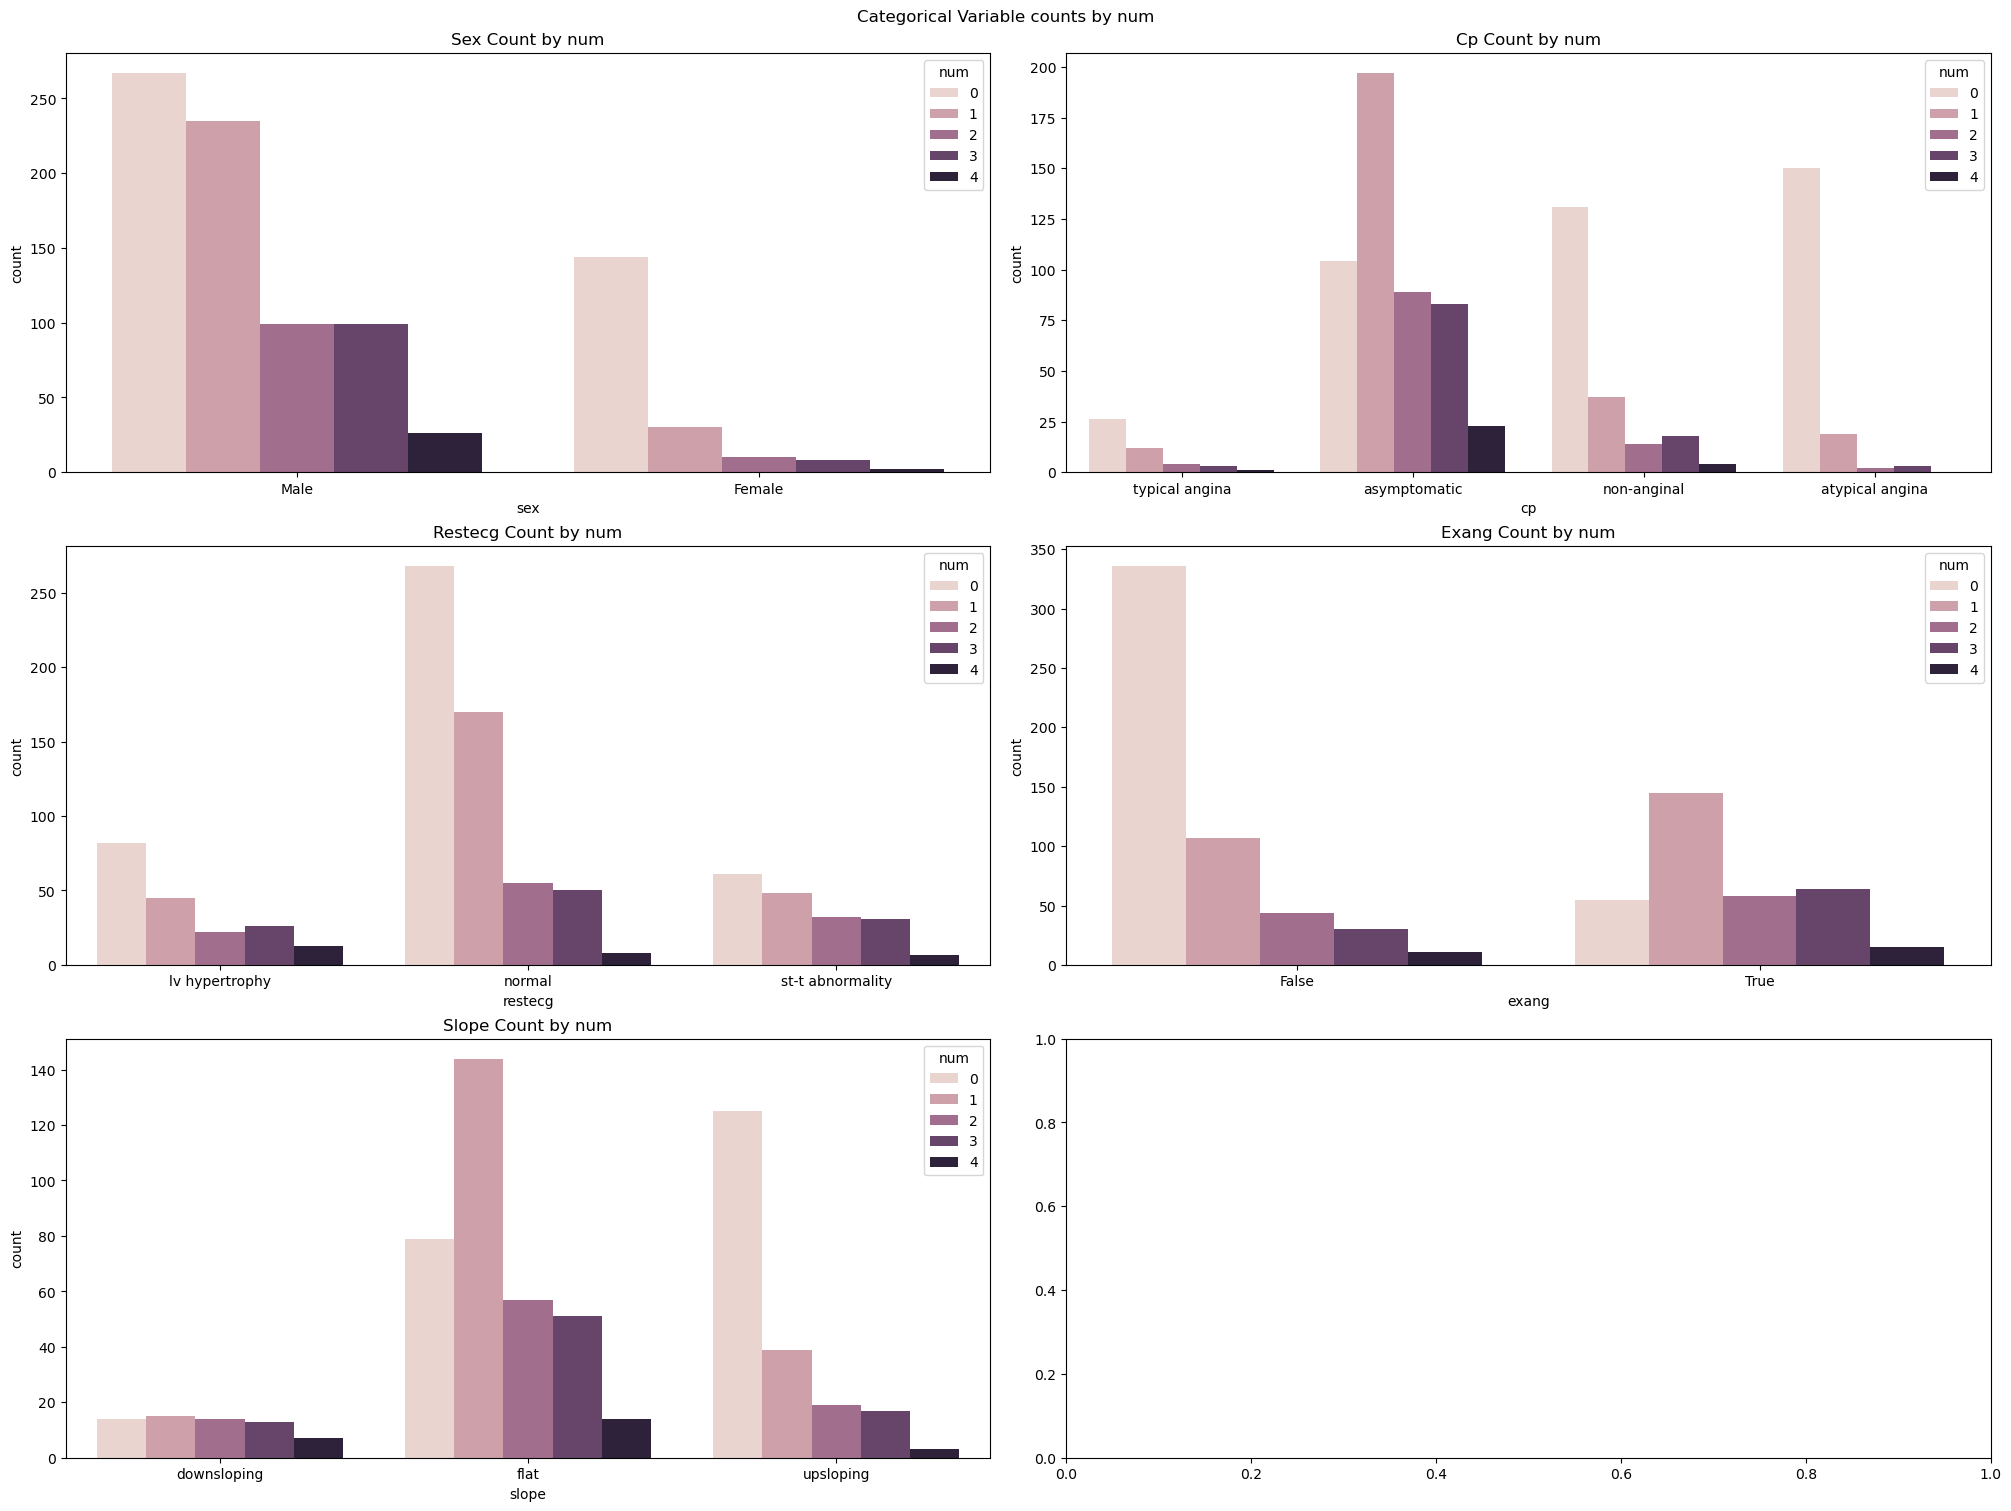

In [242]:
# For categorical Variables
categorical_vars = ['sex', 'cp', 'restecg', 'exang', 'slope']

fig, axes = plt.subplots(nrows=3, ncols=int(len(categorical_vars)/2), figsize=(20, 15), constrained_layout=True)
axes = axes.flatten()
for i, var in enumerate(categorical_vars):
    sns.countplot(data=df_final_full, x=var, hue='num', ax = axes[i])
    axes[i].set_title(f'{var.capitalize()} Count by num')

plt.suptitle('Categorical Variable counts by num')
plt.show()

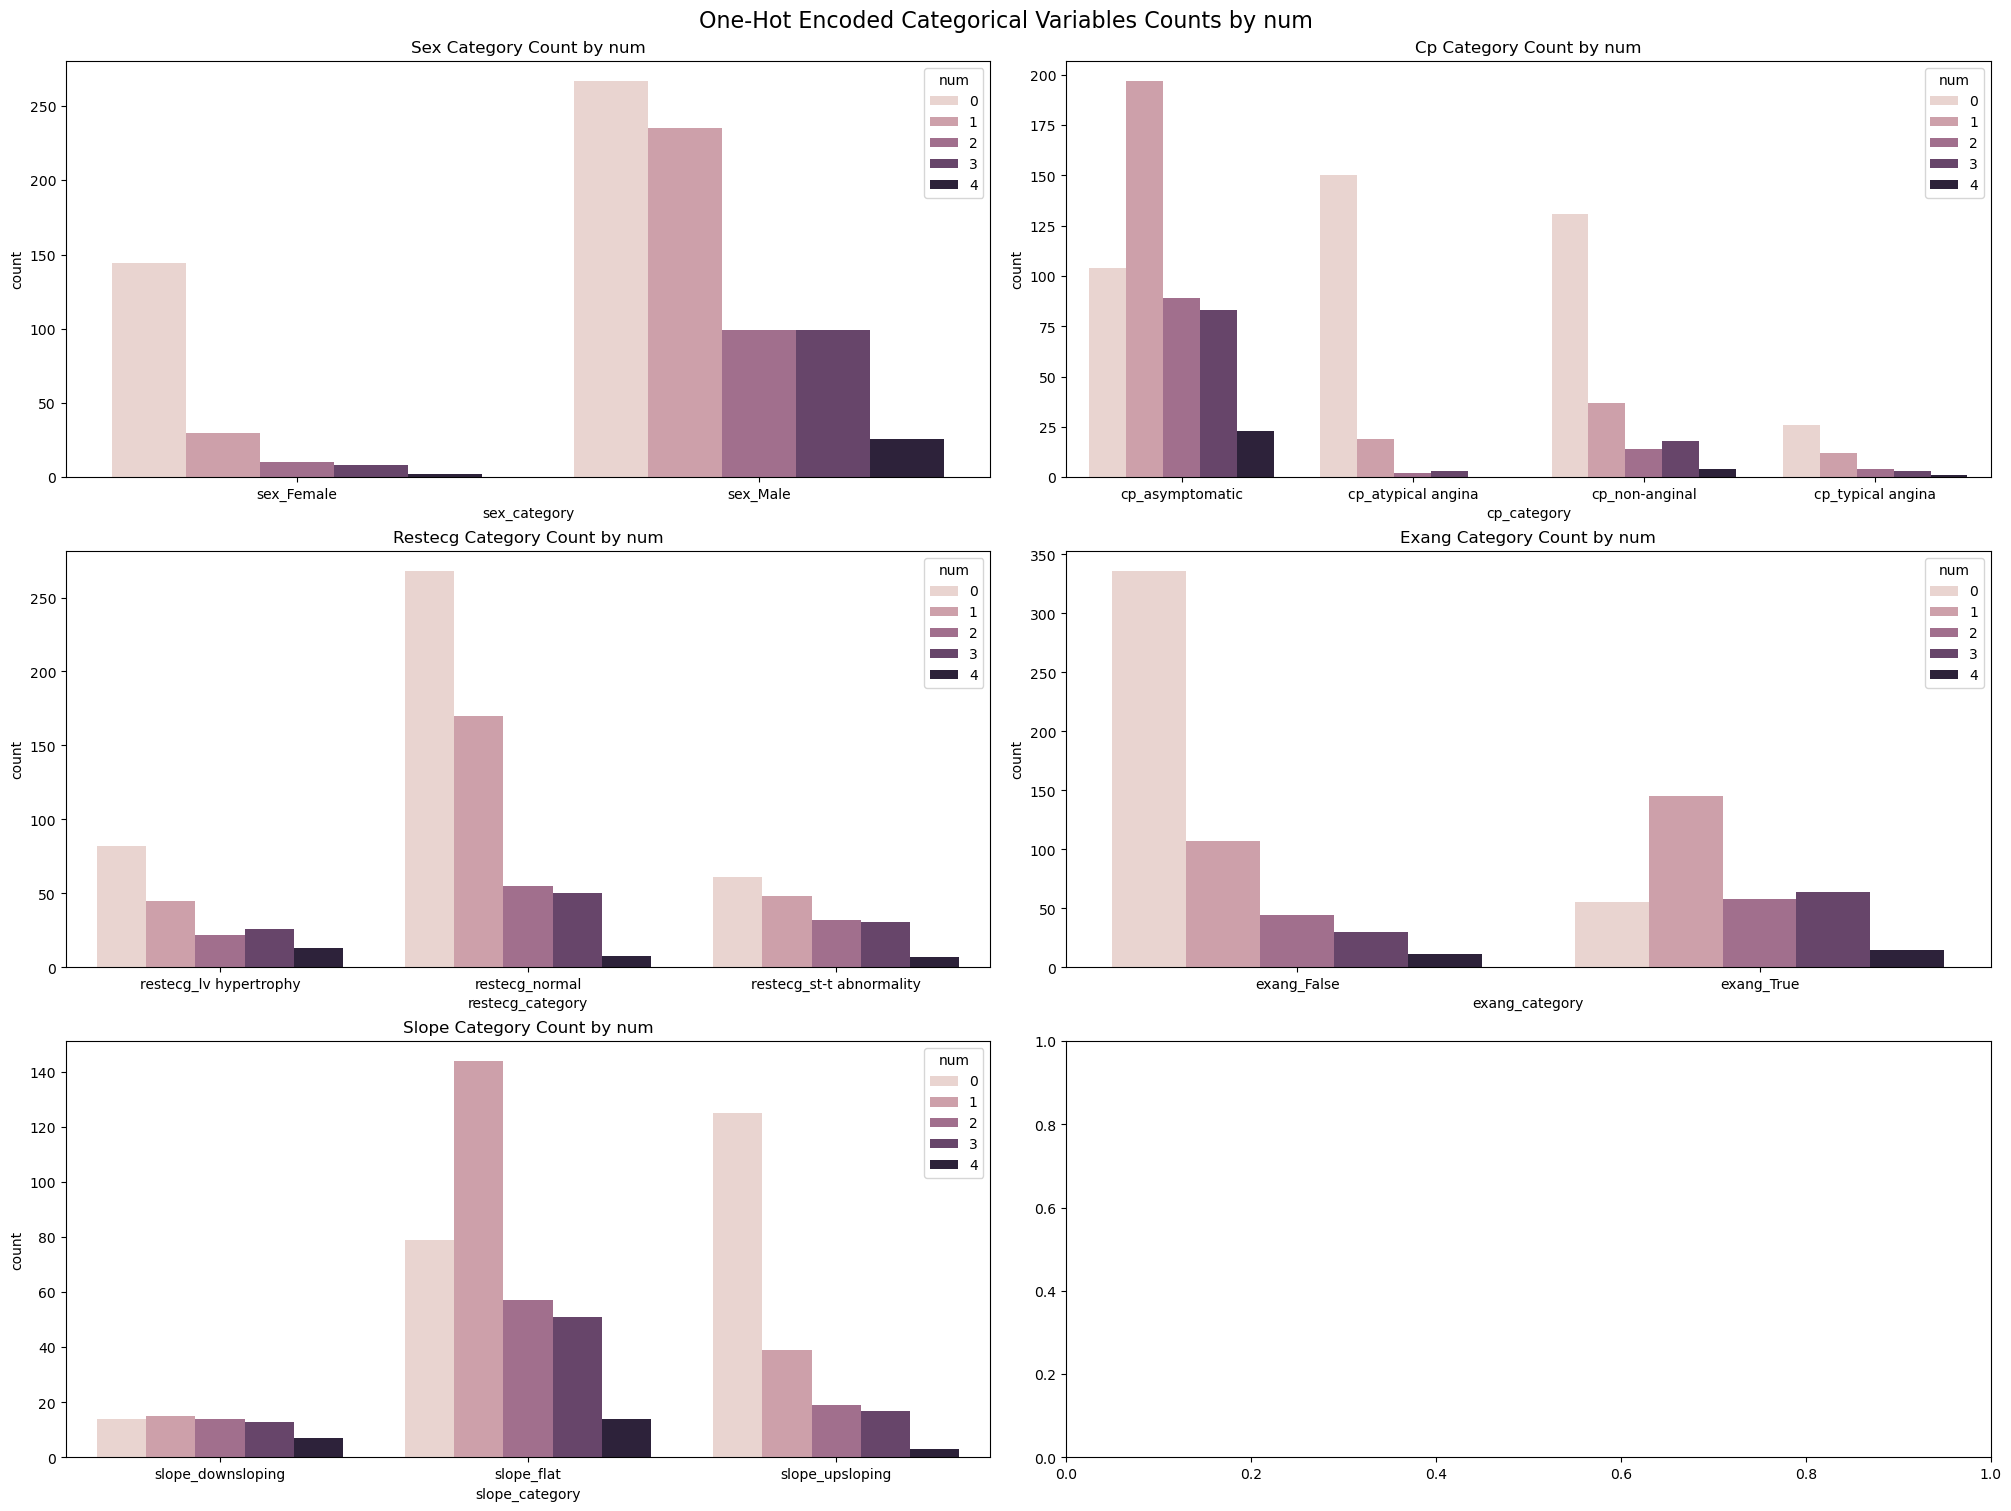

In [243]:

# For categorical variables
categorical_vars = ['sex', 'cp', 'restecg', 'exang', 'slope']

# One-hot encoded columns for each categorical variable
encoded_vars = {
    'sex': ['sex_Female', 'sex_Male'],
    'cp': ['cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina'],
    'restecg': ['restecg_lv hypertrophy', 'restecg_normal', 'restecg_st-t abnormality'],
    'exang': ['exang_False', 'exang_True'],
    'slope': ['slope_downsloping', 'slope_flat', 'slope_upsloping']
}

# Create a 3x2 grid of subplots to display the plots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 15), constrained_layout=True)
axes = axes.flatten()

# Loop over the categorical variables and their one-hot encoded columns
for i, var in enumerate(categorical_vars):
    encoded_columns = encoded_vars[var]
    df_encoded = df_final_full[encoded_columns + ['num']]  # select one-hot columns and the target 'num'
    
    # Melt the dataframe to have a column for the one-hot categories and their values
    df_melted = df_encoded.melt(id_vars='num', value_vars=encoded_columns, 
                                 var_name=f'{var}_category', value_name='count')
    
    # Filter out rows where the 'count' is 0 (i.e., non-occurring categories)
    df_melted = df_melted[df_melted['count'] == 1]
    
    # Plot the count of each category per 'num'
    sns.countplot(data=df_melted, x=f'{var}_category', hue='num', ax=axes[i])
    axes[i].set_title(f'{var.capitalize()} Category Count by num')

# Set a title for the whole figure
plt.suptitle('One-Hot Encoded Categorical Variables Counts by num', fontsize=16)
plt.show()

**Note that now the different predictor classes seem unbalanced, but that is ok. When dealing with imbalanced datasets, the priority is balancing the response variable, as otherwise the model would bias towards sides of the output that could potentially be misleading despite predictors.**

<a id="feature"></a>
### Feature Importance

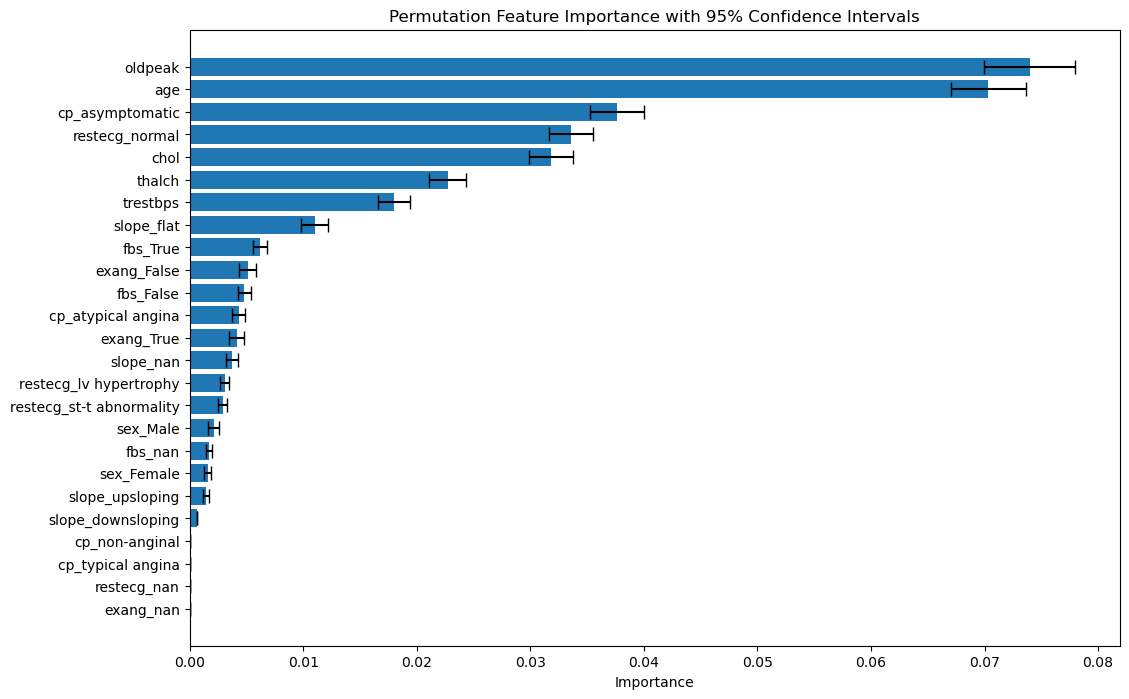

            Feature  Importance  Importance_std  CI_lower  CI_upper
4           oldpeak    0.073982        0.006474  0.069969  0.077994
0               age    0.070334        0.005355  0.067015  0.073654
7   cp_asymptomatic    0.037629        0.003849  0.035244  0.040015
15   restecg_normal    0.033556        0.003145  0.031607  0.035505
2              chol    0.031854        0.003126  0.029917  0.033792


In [244]:
## FEATURE IMPORTANCE AFTER IMPUTATION AND NORMALIZATION 
# Initialize the Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Prepare your features and target variable (X and y)
X_feature = X_train.drop(['age_percentile'], axis=1)  
y_feature = y_train

# Fit the model on the resampled training data
rf.fit(X_feature, y_feature)

repeats = 10 
# Calculate permutation importance
perm_importance = permutation_importance(rf, X_feature, y_feature, n_repeats=repeats, random_state=42)

# Create a DataFrame for permutation importance
perm_importance_df = pd.DataFrame({
    'Feature': X_feature.columns,
    'Importance': perm_importance.importances_mean,  # Mean of the importance across all repetitions
    'Importance_std': perm_importance.importances_std  # Standard deviation of the importance
    })

# Calculate 95% confidence intervals (assuming normal distribution)
perm_importance_df['CI_lower'] = perm_importance_df['Importance'] - 1.96 * perm_importance_df['Importance_std'] / (repeats ** 0.5)
perm_importance_df['CI_upper'] = perm_importance_df['Importance'] + 1.96 * perm_importance_df['Importance_std'] / (repeats ** 0.5)

# Sort by importance
perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=False)

# Plot the permutation importances with confidence intervals
plt.figure(figsize=(12, 8))
plt.barh(perm_importance_df['Feature'], perm_importance_df['Importance'], xerr=[perm_importance_df['Importance'] - perm_importance_df['CI_lower'], perm_importance_df['CI_upper'] - perm_importance_df['Importance']], capsize=5)
plt.xlabel('Importance')
plt.title('Permutation Feature Importance with 95% Confidence Intervals')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

# Display top important features by permutation importance
print(perm_importance_df.head())

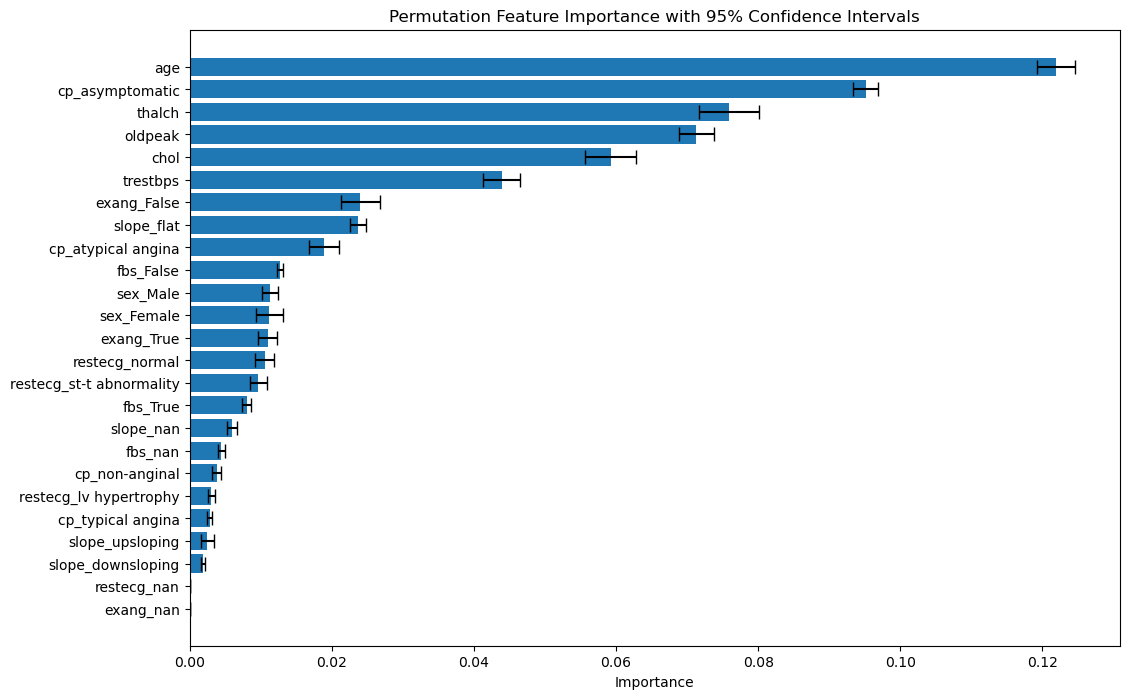

           Feature  Importance  Importance_std  CI_lower  CI_upper
0              age    0.121957        0.004315  0.119282  0.124631
7  cp_asymptomatic    0.095109        0.002803  0.093371  0.096846
3           thalch    0.075870        0.006767  0.071675  0.080064
4          oldpeak    0.071304        0.003925  0.068872  0.073737
2             chol    0.059239        0.005858  0.055608  0.062870


In [245]:
## FEATURE IMPORTANCE BEFORE IMPUTATION AND NORMALIZATION 

X = df_imputed.drop(columns=['num', 'age_percentile'], axis = 1)
y = df['num']

# Fit the model on the filtered data
rf.fit(X, y)

repeats = 10 
# Calculate permutation importance
perm_importance = permutation_importance(rf, X, y, n_repeats=repeats, random_state=42)

# Create a DataFrame for permutation importance, including confidence intervals
perm_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_importance.importances_mean,  # Mean of the importance across all repetitions
    'Importance_std': perm_importance.importances_std  # Standard deviation of the importance
})

# Calculate 95% confidence intervals (assuming normal distribution)
perm_importance_df['CI_lower'] = perm_importance_df['Importance'] - 1.96 * perm_importance_df['Importance_std'] / (repeats ** 0.5)
perm_importance_df['CI_upper'] = perm_importance_df['Importance'] + 1.96 * perm_importance_df['Importance_std'] / (repeats ** 0.5)

# Sort by importance
perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=False)

# Plot the permutation importances with confidence intervals
plt.figure(figsize=(12, 8))
plt.barh(perm_importance_df['Feature'], perm_importance_df['Importance'], xerr=[perm_importance_df['Importance'] - perm_importance_df['CI_lower'], perm_importance_df['CI_upper'] - perm_importance_df['Importance']], capsize=5)
plt.xlabel('Importance')
plt.title('Permutation Feature Importance with 95% Confidence Intervals')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

# Display top important features by permutation importance
print(perm_importance_df.head())

<a id='ifplots'></a>
### Important Feature Plots

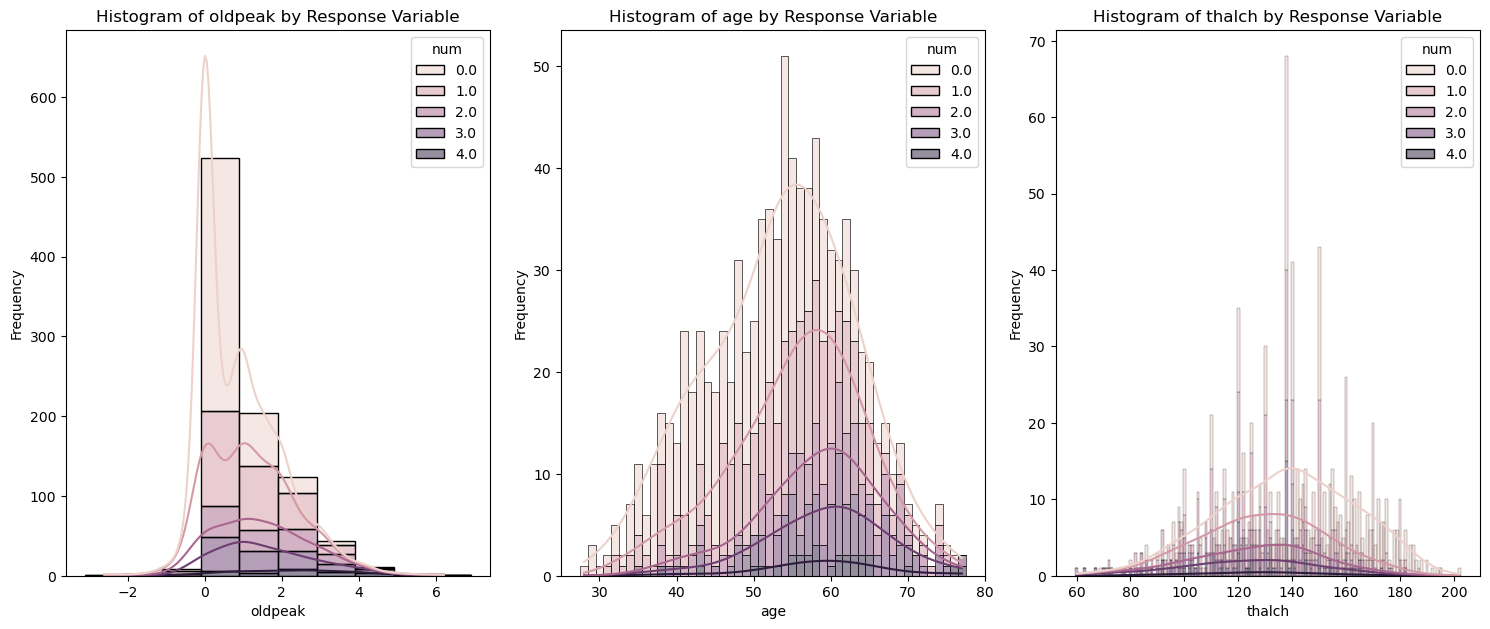

In [246]:
top_cont_features = ['oldpeak', 'age', 'thalch']

# Set up the figure size
plt.figure(figsize=(15, 12))

# Create histograms (or boxplots) for each important feature vs. response variable (num)
for i, feature in enumerate(top_cont_features):
    plt.subplot(2, 3, i+1)  # Adjust the number of rows and columns as needed
    
    # Plotting histogram by response variable class
    sns.histplot(data=df_imputed, x=feature, hue='num', kde=True, multiple='stack', discrete=True)
    
    plt.title(f'Histogram of {feature} by Response Variable')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

# Show the plot
plt.tight_layout()
plt.show()

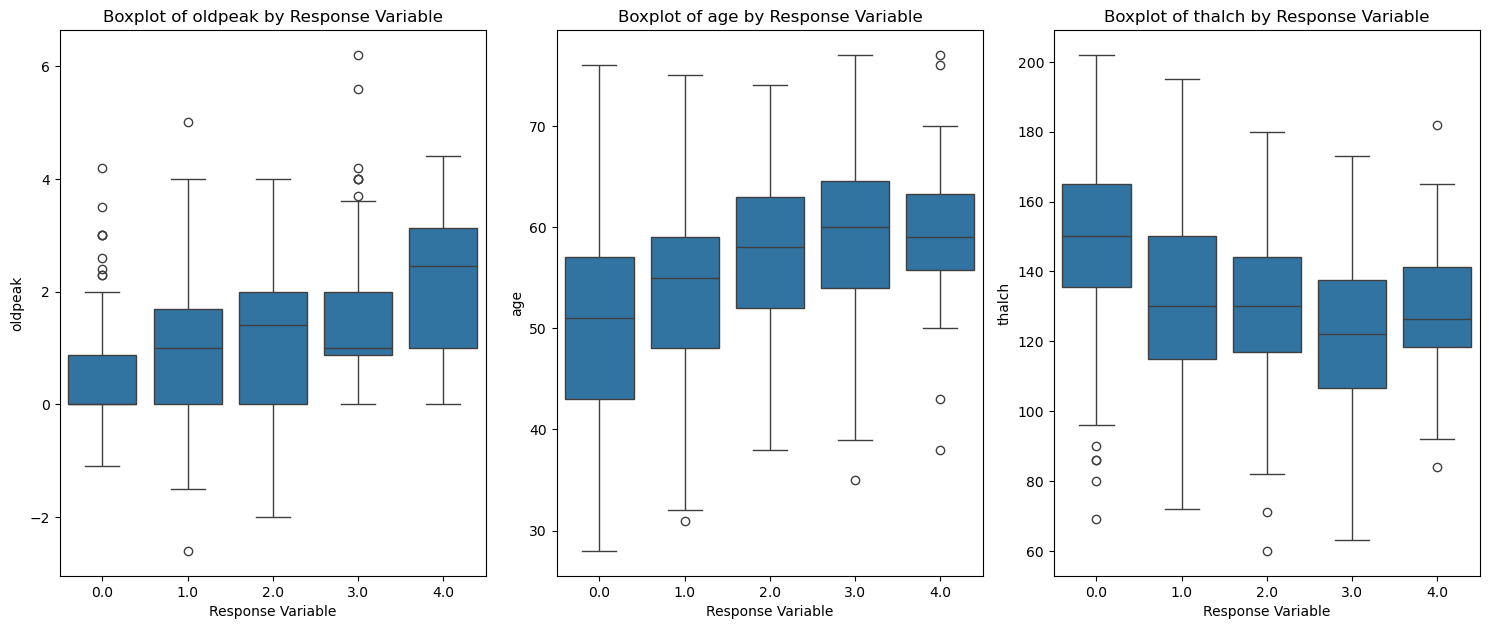

In [247]:
# Create boxplots for each important feature vs. response variable (num)
plt.figure(figsize=(15, 12))

for i, feature in enumerate(top_cont_features):
    plt.subplot(2, 3, i+1)
    
    # Create a boxplot to visualize feature distribution by response variable class
    sns.boxplot(data=df_imputed, x='num', y=feature)
    
    plt.title(f'Boxplot of {feature} by Response Variable')
    plt.xlabel('Response Variable')
    plt.ylabel(feature)

# Show the plot
plt.tight_layout()
plt.show()

/var/folders/2j/265z53h12ggd9bsj771vs11w0000gn/T/ipykernel_19634/1987663864.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_imputed, x='num', y=feature, jitter=True, palette='viridis', alpha=0.7)
/var/folders/2j/265z53h12ggd9bsj771vs11w0000gn/T/ipykernel_19634/1987663864.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_imputed, x='num', y=feature, jitter=True, palette='viridis', alpha=0.7)
/var/folders/2j/265z53h12ggd9bsj771vs11w0000gn/T/ipykernel_19634/1987663864.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.strippl

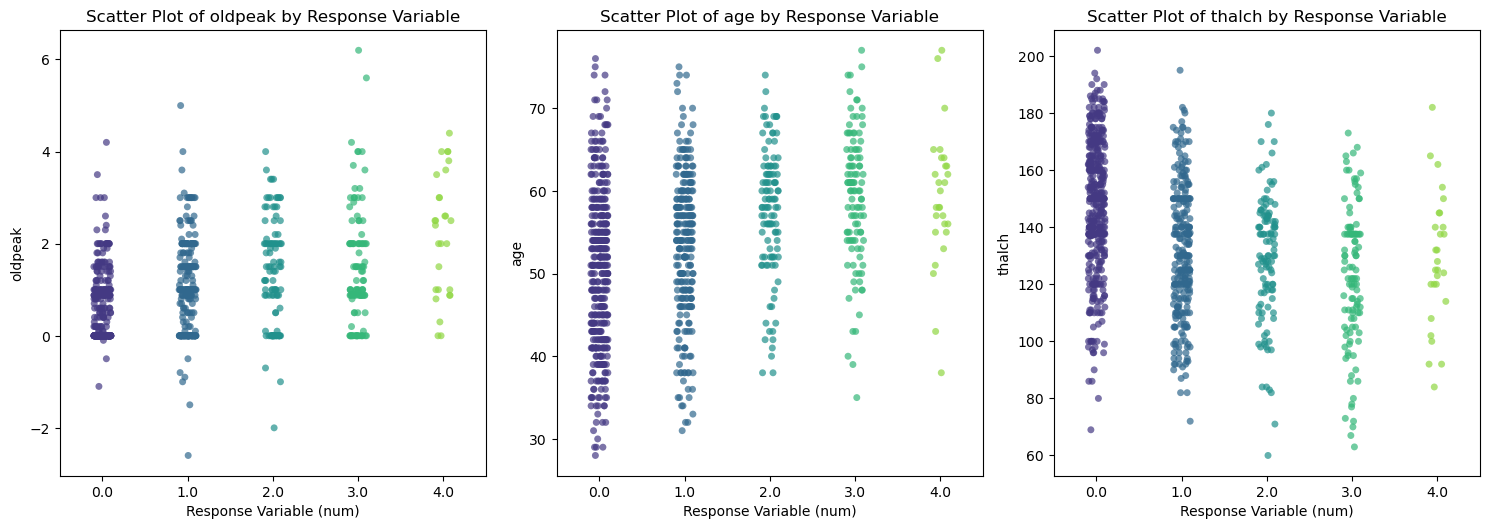

In [248]:
plt.figure(figsize=(15, 10))

# Loop through each important feature for scatter plotting
for i, feature in enumerate(top_cont_features):
    plt.subplot(2, 3, i+1)
    
    # Scatter plot with slight jitter on 'num' axis to avoid overlap
    sns.stripplot(data=df_imputed, x='num', y=feature, jitter=True, palette='viridis', alpha=0.7)
    
    plt.title(f'Scatter Plot of {feature} by Response Variable')
    plt.xlabel('Response Variable (num)')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

<a id="correl"></a>
### Correlation Plots

In [249]:
## MAKE MELTED DATAFRAME FOR ONE HOT ENCODED VALUES

# For categorical variables
categorical_vars = ['sex', 'cp', 'restecg', 'exang', 'slope']

# One-hot encoded columns for each categorical variable
encoded_vars = {
    'sex': ['sex_Female', 'sex_Male'],
    'cp': ['cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina'],
    'restecg': ['restecg_lv hypertrophy', 'restecg_normal', 'restecg_st-t abnormality'],
    'exang': ['exang_False', 'exang_True'],
    'slope': ['slope_downsloping', 'slope_flat', 'slope_upsloping']}

# Create a copy of your original dataframe with one-hot encoded variables
df_melted = df_model_final.copy()

# Iterate over each categorical variable and melt the one-hot columns
for var, columns in encoded_vars.items():
    # Find rows where the value is 1 for each one-hot column, and set the variable to that category name
    df_melted[var] = df_melted[columns].idxmax(axis=1)
    # Replace column names with the category label
    df_melted[var] = df_melted[var].apply(lambda x: x.split('_', 1)[-1] if pd.notna(x) else 'Unknown')

# Drop the original one-hot columns since we now have the original categorical variable back
df_melted = df_melted.drop(columns=[col for cols in encoded_vars.values() for col in cols])

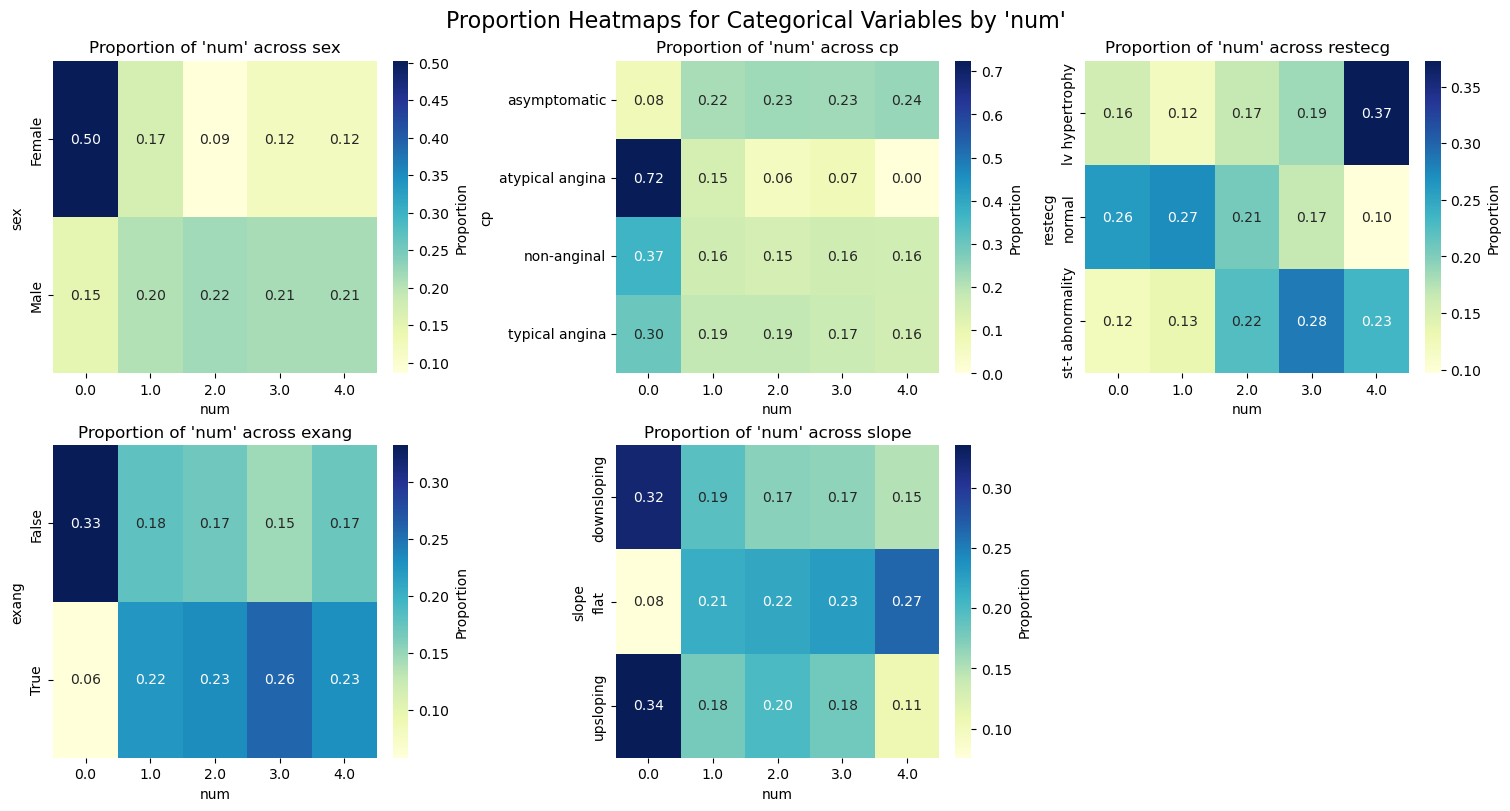

In [250]:
categorical_vars = ['sex', 'cp', 'restecg', 'exang', 'slope']

num_vars = len(categorical_vars)
ncols = 3
nrows = (num_vars + ncols - 1) // ncols  # Calculates rows to fit variables across 2 rows

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 8), constrained_layout=True)

# Flatten axes to iterate easily, and plot each variable
for i, var in enumerate(categorical_vars):
    # Create a contingency table
    crosstab = pd.crosstab(df_melted[var], df_melted['num'], normalize="index")

    # Plot the heatmap in the appropriate subplot
    sns.heatmap(crosstab, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Proportion'},
                ax=axes.flat[i])
    axes.flat[i].set_title(f"Proportion of 'num' across {var}")
    axes.flat[i].set_xlabel("num")
    axes.flat[i].set_ylabel(var)

# Turn off any unused subplots
for j in range(i + 1, nrows * ncols):
    axes.flat[j].set_visible(False)

plt.suptitle("Proportion Heatmaps for Categorical Variables by 'num'", fontsize=16)
plt.show()

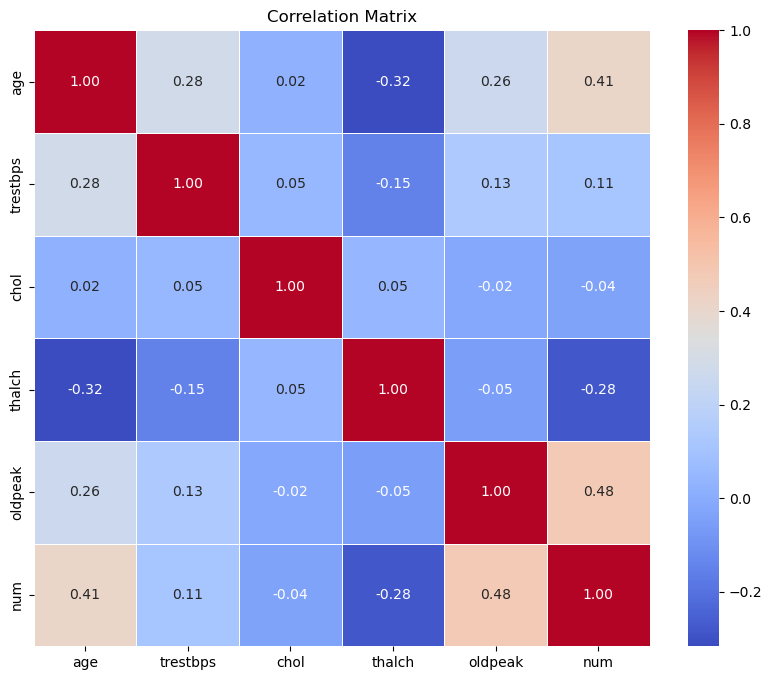

In [251]:
# Select numeric columns from df_model_final (excluding one-hot encoded variables)
df_numeric = df_model_final[['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num']]

# Compute the correlation matrix
corr = df_numeric.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', square=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [252]:
print(corr)

               age  trestbps      chol    thalch   oldpeak       num
age       1.000000  0.281297  0.023110 -0.316148  0.255034  0.410730
trestbps  0.281297  1.000000  0.049631 -0.148059  0.133870  0.112084
chol      0.023110  0.049631  1.000000  0.046515 -0.016343 -0.037328
thalch   -0.316148 -0.148059  0.046515  1.000000 -0.052765 -0.284714
oldpeak   0.255034  0.133870 -0.016343 -0.052765  1.000000  0.475787
num       0.410730  0.112084 -0.037328 -0.284714  0.475787  1.000000


<a id='tuning'></a>
# 4. Model Tuning

### Random Forest Model
<a id='baseline-rf'></a>

In [253]:
X = df_model_final.drop(columns=['num',])  
y = df_model_final['num']  


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred)

# Display accuracy
print(f"Accuracy: {accuracy_rf:.4f}")

Accuracy: 0.7964


### Gradient Boosting Model
<a id='baseline-gb'></a>

In [254]:
# boosting model
X = df_model_final.drop(columns=['num'])  
y = df_model_final['num']  # Target variable 'num'

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [255]:
gb = GradientBoostingClassifier(random_state=42)

In [256]:

param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5]
}

grid_search = GridSearchCV(estimator=gb, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)


In [257]:
grid_search.fit(X_train, y_train)
print(f"Best Hyperparameters: {grid_search.best_params_}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}


In [258]:
y_pred = grid_search.best_estimator_.predict(X_test)

accuracy_gb = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_gb:.4f}")

Accuracy: 0.7994


### XGBClassifier Model
<a id='baseline-xgb'></a>

In [259]:
from xgboost import XGBClassifier
X = df_model_final.drop(columns=['num'])  
y = df_model_final['num']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb = XGBClassifier(random_state=42)

In [260]:
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the ensemble
    'learning_rate': [0.01, 0.05, 0.1],  # Step size shrinking
    'max_depth': [3, 4, 5],  # Maximum depth of trees
    'subsample': [0.8, 1.0],  # Proportion of samples used for each tree
    'colsample_bytree': [0.8, 1.0]  # Proportion of features used for each tree
}

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

In [261]:
grid_search.fit(X_train, y_train)
print(f"Best Hyperparameters: {grid_search.best_params_}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Hyperparameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [262]:
y_pred = grid_search.best_estimator_.predict(X_test)

# Calculate accuracy
accuracy_xgb = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_xgb:.4f}")

Accuracy: 0.8419


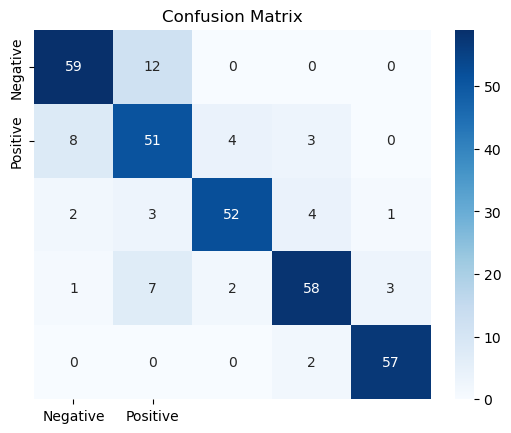

In [263]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix")
plt.show()

### PCA
<a id='pca'></a>

A potentially important tool to reduce dimensionality of this dataset is PCA, so lets use it and see what it does to our models.

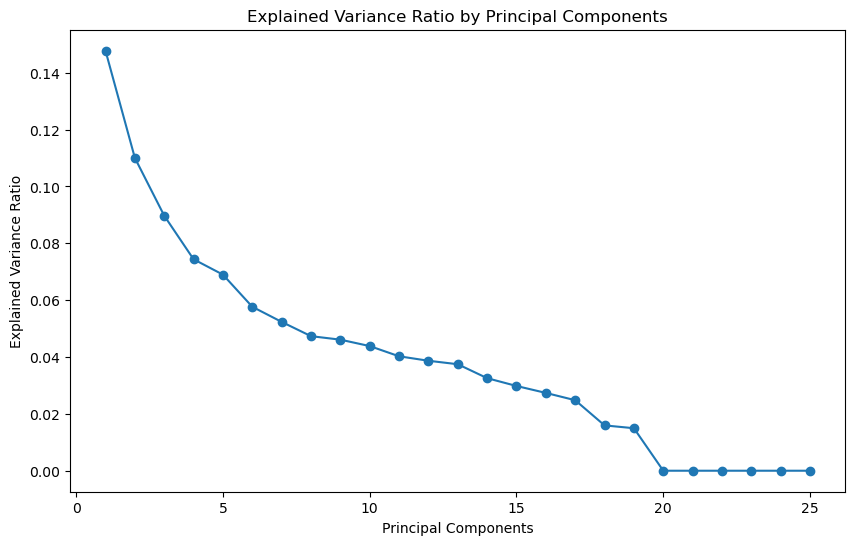

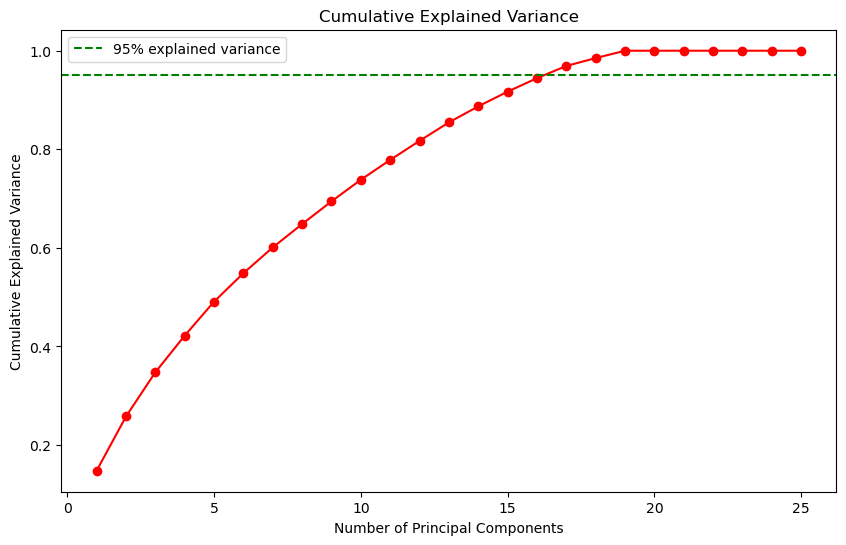

        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -1.910161 -0.779844  1.368748  1.419974 -0.711507 -1.212115  0.871517   
1 -1.150626  2.760398 -1.101170  2.843465  0.183745  0.636846  1.373346   
2  1.651774 -1.595667 -0.420616  0.389094  0.574445 -1.565010 -0.648341   
3  1.793800  0.407884  3.489051 -1.272973 -1.453340 -0.623634  1.040859   
4  1.277980  1.624375 -0.780380  1.687715 -0.784801  0.007592 -2.141561   

        PC8       PC9      PC10  ...      PC16      PC17      PC18      PC19  \
0 -1.317563  0.015091  1.737406  ...  0.991039  0.170189 -1.021356  0.035830   
1  1.723888 -0.857606 -0.270690  ...  1.554880  2.208221  0.526398 -0.451299   
2  0.613496  0.340174 -0.247890  ...  0.911535 -0.482191 -0.225595 -0.317464   
3  0.249577 -1.274199 -0.173970  ...  2.428049 -0.403682 -0.126679 -0.591656   
4 -0.418001 -0.022684  0.291718  ... -0.494774 -0.449139  1.023890 -0.844046   

           PC20          PC21          PC22          PC23          P

In [265]:
# PCA Analysis
columns_to_use = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak',
                  'sex_Female', 'sex_Male', 'cp_asymptomatic', 'cp_atypical angina',
                  'cp_non-anginal', 'cp_typical angina', 'fbs_False', 'fbs_True',
                  'fbs_nan', 'restecg_lv hypertrophy', 'restecg_normal',
                  'restecg_st-t abnormality', 'restecg_nan', 'exang_False', 'exang_True',
                  'exang_nan', 'slope_downsloping', 'slope_flat', 'slope_upsloping',
                  'slope_nan']

df_pca = df_model_final[columns_to_use]

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_pca)

pca = PCA()
df_pca_transformed = pca.fit_transform(df_scaled)

explained_variance_ratio = pca.explained_variance_ratio_

# Plot 
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o')
plt.title('Explained Variance Ratio by Principal Components')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.show()

cumulative_explained_variance = explained_variance_ratio.cumsum()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', color='red')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='g', linestyle='--', label="95% explained variance")
plt.legend()
plt.show()


pca_components_df = pd.DataFrame(df_pca_transformed, columns=[f'PC{i+1}' for i in range(df_scaled.shape[1])])

print(pca_components_df.head())

We also have ideas with regards to using PCA. As we can see it takes 17 principle components (of 25 included predictors, no ‘num’ and no ‘age_percentile’) in order to explain 95% of the variance. We know this means that there is little redundancy between the features and that they all provide at least a little value in our predictive model. As such, even though there is minimal room for removing dimensionality without losing variance, it may be worth experimenting on. This is because, we still hope for this to be highly generalizable and want our model to prioritize the main components of the variance. So let's explore...


In [266]:
# Split data and fit PCA to training data

X_train, X_val, y_train, y_val = train_test_split(df_scaled, y, test_size=0.2, random_state=42)

# Apply PCA
pca = PCA()
X_train_pca = pca.fit_transform(X_train)

X_val_pca = pca.transform(X_val)

##############################

## Now with this data set we can check for whether reducing dimensionality via PCA helps the models

In [267]:
## We will use the 3 models from above, but not do hyperparameter tuning

# Random Forest

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_pca, y_train)
y_pred = rf.predict(X_val_pca)

accuracy_pca = accuracy_score(y_val, y_pred)

# Display accuracy
print(f"Accuracy PCA: {accuracy_pca:.4f}")
print(f"Accuracy non-PCA: {accuracy_rf:.4f}")


Accuracy PCA: 0.8298
Accuracy non-PCA: 0.7964


In [268]:
# Gradient boosting
gb = GradientBoostingClassifier(learning_rate=0.05, 
                                max_depth= 5, 
                                n_estimators=200, 
                                random_state=42)

gb.fit(X_train_pca, y_train)

y_pred = gb.predict(X_val_pca)


accuracy_pca = accuracy_score(y_val, y_pred)

# Display accuracy
print(f"Accuracy PCA: {accuracy_pca:.4f}")
print(f"Accuracy non-PCA: {accuracy_gb:.4f}")


Accuracy PCA: 0.7964
Accuracy non-PCA: 0.7994


In [269]:
# XG Boost
xgb = XGBClassifier(colsample_bytree = 1.0, 
                    learning_rate=0.1, 
                    max_depth = 5, 
                    n_estimators = 200, 
                    subsample = 0.8, 
                    random_state=42)

xgb.fit(X_train_pca, y_train)
y_pred = xgb.predict(X_val_pca)

# Calculate accuracy
accuracy_pca = accuracy_score(y_val, y_pred)

#Display accuracy
print(f"Accuracy PCA: {accuracy_pca:.4f}")
print(f"Accuracy non-PCA: {accuracy_xgb:.4f}")


Accuracy PCA: 0.8359
Accuracy non-PCA: 0.8419


From this exploration we can see that it is not necessarily beneficial to use PCA to reduce dimensionality. Our Random Forest model had quite large gains by using it, but gradient boosting and XG Boost lost ground in terms of accuracy. As such, in our final model pipeline it might be worth using PCA for the Random Forest model testing, but I suspect, given that XG Boost as proven to be most accurate so far, that our final model will use that method and thus not require PCA.

### VIF Analysis
<a id='vif'></a>
Per the recommendations of our TF Siona, we wanted to do more collinearity analysis, specifically, VIF. See the added analysis here.

In [270]:
df_model_final.columns

Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'age_percentile',
       'sex_Female', 'sex_Male', 'cp_asymptomatic', 'cp_atypical angina',
       'cp_non-anginal', 'cp_typical angina', 'fbs_False', 'fbs_True',
       'fbs_nan', 'restecg_lv hypertrophy', 'restecg_normal',
       'restecg_st-t abnormality', 'restecg_nan', 'exang_False', 'exang_True',
       'exang_nan', 'slope_downsloping', 'slope_flat', 'slope_upsloping',
       'slope_nan', 'num'],
      dtype='object')

In [271]:

# VIF analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define the columns for VIF analysis
# drop one column per one-hot encoded category 
columns_to_include = [
    'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'age_percentile',
    'sex_Female', 'cp_asymptomatic', 'cp_atypical angina',
    'cp_non-anginal', 'fbs_False', 'restecg_lv hypertrophy',
    'restecg_normal', 'exang_False', 'slope_downsloping', 'slope_flat'
]

df_vif = df_model_final[columns_to_include]

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = df_vif.columns
vif_data["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]

# Display the results
print(vif_data)



                   Feature        VIF
0                      age   8.533037
1                 trestbps   1.172238
2                     chol   1.057559
3                   thalch   1.555254
4                  oldpeak   1.913294
5           age_percentile  27.104291
6               sex_Female   1.339956
7          cp_asymptomatic  10.928055
8       cp_atypical angina   2.567332
9           cp_non-anginal   3.232974
10               fbs_False   4.407352
11  restecg_lv hypertrophy   2.632478
12          restecg_normal   3.557613
13             exang_False   2.544840
14       slope_downsloping   1.839100
15              slope_flat   3.170712


We can see moderate/acceptable levels of collinearity for most predictor variables, except for a few. Most notably is age_percentile. This likely has such a high multicollinearity because of its relation to the age predictor. As such we found it useful to drop this predictor from the models below. Furthermore, the  

Lets run this analysis again below without age_percentile to see how it improves. 

In [272]:
# VIF analysis

# Define the columns for VIF analysis
# drop one column per one-hot encoded category 
columns_to_include = [
    'age', 'trestbps', 'chol', 'thalch', 'oldpeak',
    'sex_Female', 'cp_asymptomatic', 'cp_atypical angina',
    'cp_non-anginal', 'fbs_False', 'restecg_lv hypertrophy',
    'restecg_normal', 'exang_False', 'slope_downsloping', 'slope_flat'
]

df_vif = df_model_final[columns_to_include]

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = df_vif.columns
vif_data["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]

# Display the results
print(vif_data)

                   Feature       VIF
0                      age  1.493536
1                 trestbps  1.167724
2                     chol  1.057558
3                   thalch  1.554872
4                  oldpeak  1.903619
5               sex_Female  1.339953
6          cp_asymptomatic  5.055853
7       cp_atypical angina  1.855363
8           cp_non-anginal  2.059404
9                fbs_False  4.320753
10  restecg_lv hypertrophy  2.617711
11          restecg_normal  3.507191
12             exang_False  2.420124
13       slope_downsloping  1.838229
14              slope_flat  3.147487


Under the guidance of our TF Siona, we took a deeper look into the mulitcollinearity of our predictors. These are much better values, and show moderate to low multicollinearity across all of our predictors. We now are able to feel much more confident in these predictors. By addressing multicollinearity, the final model is less sensitive to overfitting and is better equipped to generalize across datasets. The updated pipeline using both the multicollinearity corrections and PCA performed with consistent classification metrics, and the other models (random forest and boosting) improved due to the reduced feature noise. 

### Multicollinearity Analysis Model Selection

We will now run through our three models to see which shows the most promise after recognizing the multicollinearity. The change we made was to remove the 'age_percentile' variable as it is highly collinear and thus is redundant in our models. 

#### Random Forest (multicollinearity check)

In [273]:
X = df_model_final.drop(columns=['num', 'age_percentile'])  
y = df_model_final['num']  


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

# Display accuracy
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8176


<div style = "background: light grey; border: thin solid black; border-radius: 2px; padding: 5px">

**Note: This is the improved value after our multicollinearity analysis**

Improved from 0.7964 to the above 0.8176 after we dropped the age_percentile predictor (very multicollinear that it biases our model). The improvement is valuable.

</div>

#### Gradient Boosting (multicollinearity check)

In [274]:
# boosting model
X = df_model_final.drop(columns=['num', 'age_percentile'])  
y = df_model_final['num']  # Target variable 'num'

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gb = GradientBoostingClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [5, 10, 20]
}

grid_search = GridSearchCV(estimator=gb, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)
print(f"Best Hyperparameters: {grid_search.best_params_}")

y_pred = grid_search.best_estimator_.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
Accuracy: 0.8024


<div style = "background: light grey; border: thin solid black; border-radius: 2px; padding: 5px">

**Note: This is the improved value after our multicollinearity analysis**

Improved from 0.7994 to the above 0.8024 after we dropped the age_percentile predictor (very multicollinear that it biases our model). The improvement is valuable.

</div>

#### XG Boost (multicollinearity check)

In [275]:
from xgboost import XGBClassifier
X = df_model_final.drop(columns=['num', 'age_percentile'])  
y = df_model_final['num']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb = XGBClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the ensemble
    'learning_rate': [0.01, 0.05, 0.1, 0.3, 0.5],  # Step size shrinking
    'max_depth': [3, 4, 5],  # Maximum depth of trees
    'subsample': [0.8, 1.0],  # Proportion of samples used for each tree
    'colsample_bytree': [0.8]  # Proportion of features used for each tree
}

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)
print(f"Best Hyperparameters: {grid_search.best_params_}")
y_pred = grid_search.best_estimator_.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 0.8328


<div style = "background: light grey; border: thin solid black; border-radius: 2px; padding: 5px">

**Note: This accuracy was actually worse after dropping 'age_percentile'**

Went from 0.8419 to the above 0.8328. Might be worth not dropping age_percentile if we are seeking the model with best accuracy, but at the same time it is a small drop, and might be beneficial if we hope for our model to be more generalizable.

</div>

<div style = "background: light grey; border: thin solid black; border-radius: 2px; padding: 5px">

#### **Conclusion on Multicollinearity analysis:**

From the above, we identified that we should only drop the age_percentile predictor for Random Forest and Gradient Boosting models. After dropping it, we realized that for our random forest and boosting models, our metrics improved. Removing age_percentile forced the models to rely on the other, less redundant features which improved their predictive performance. However, performance with XGBoost worsened after removing age_percentile. As such, we will keep that predictor there for our final model tests. In the end we seek the most accurate model. To be clear we are not sacrificing generalizability because this is on the test set, so we can prioritize accuracy here.

</div>


<a id='final'></a>
# 5. Final Model Selection

### Final Model Pipelines
- Random Forest will utilize of PCA and drop 'age_percentile'
- Gradient Boosting will utilize PCA and drop 'age_percentile'
- XG Boost will not do either of these things

For all models we now must fine tune their hyperparameters

<a id='final-rf'></a>
#### Final Random Forest

In [276]:
X = df_model_final.drop(columns=['num', 'age_percentile'])  
y = df_model_final['num']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply PCA
pca = PCA()
X_train_pca = pca.fit_transform(X_train)

X_test_pca = pca.transform(X_test)

# Fit Random Forest

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200, 300, 400, 500],  # Number of trees in the ensemble
    'max_depth': [10, 15, 20, 30, 40],  # Maximum depth of trees
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

grid_search.fit(X_train_pca, y_train)
print(f"Best Hyperparameters: {grid_search.best_params_}")
y_pred = grid_search.best_estimator_.predict(X_test_pca)

accuracy = accuracy_score(y_test, y_pred)

# Display accuracy
print(f"Accuracy: {accuracy:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Hyperparameters: {'max_depth': 20, 'n_estimators': 400}
Accuracy: 0.8389


This is the best accuracy score we have seen from the Random Forest model! We have made good progress in tuning this model, and will compare to the other models to see which is our final one.

<a id='final-gb'></a>
#### Final Gradient Boosting

In [277]:
# boosting model
X = df_model_final.drop(columns=['num', 'age_percentile'])  
y = df_model_final['num']  # Target variable 'num'

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gb = GradientBoostingClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_split': [5, 10, 20]
}

grid_search = GridSearchCV(estimator=gb, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)
print(f"Best Hyperparameters: {grid_search.best_params_}")

y_pred = grid_search.best_estimator_.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")


Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 7, 'min_samples_split': 10, 'n_estimators': 100}
Accuracy: 0.8085


<a id='final-xgb'></a>
#### Final XG Boost 

In [278]:
# XG Boost Model
X = df_model_final.drop(columns=['num'])  
y = df_model_final['num']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb = XGBClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the ensemble
    'learning_rate': [0.01, 0.05, 0.1],  # Step size shrinking
    'max_depth': [3, 4, 5, 6, 7],  # Maximum depth of trees
    'subsample': [0.8, 1.0],  # Proportion of samples used for each tree
    'colsample_bytree': [0.8, 1.0]  # Proportion of features used for each tree
}


grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)
print(f"Best Hyperparameters: {grid_search.best_params_}")
y_pred = grid_search.best_estimator_.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best Hyperparameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 0.8571


Once again our tuning paid off! We found the best accuracy yet using the XG Boost model. This concludes our final model pipeline, and suggests that we should use XG Boost as our final model.

<div style = "background: light grey; border: thin solid black; border-radius: 2px; padding: 5px">

#### **Overall Selection process:**

Our model selection process started with 3 baseline models in mind: random forest, gradient boosting, and XG boosting. We chose these models because they are robust ensemble methods that generally outperform other models. This means that their ability to reduce bias and variance by combining multiple decision trees. As we narrowed down on a final model, we recognize trends in our dataset like multicollinearity and checked whether there was significant impact on model performance from that. We also delved into whether reductions of dimensionality via PCA was valuable for the models. All three models reacted differently to these changes, but we consistently found XG Boosting to produce the best results (measured by classification accuracy). As such, in our final selection process we tuned our hyperparameters via cross-validation of many different hyperparameter configurations, while also including the necessary changes for each model based off what we learned from PCA and multi-collinearity analysis. Nonetheless, XG Boost still proved the most versatile in this predictive task. Tuning it further, we found the best hyperparameter configuration as shown above, and found really good accuracy score as a result. This sets us up well to be confident in our chosen final model as a valid method of predicting the risk of heart disease by via demographic and clinical risk factors.
</div>


Now lets start exploring the results from our final model (XG Boost with the above best hyperparameters)

<a id='model_expl'></a>
# 6. Final Model Exploration

In [279]:
# final model
best_params = grid_search.best_params_
xgb_tuned = XGBClassifier(**best_params, random_state=42)

xgb_tuned.fit(X_train, y_train)

# Predict and evaluate
y_pred_fin = xgb_tuned.predict(X_test)

# Evaluation
print("Classification Report for Final Pipeline:")
print(classification_report(y_test, y_pred_fin))

Classification Report for Final Pipeline:
              precision    recall  f1-score   support

         0.0       0.83      0.83      0.83        71
         1.0       0.69      0.79      0.74        66
         2.0       0.93      0.85      0.89        62
         3.0       0.94      0.83      0.88        71
         4.0       0.94      1.00      0.97        59

    accuracy                           0.86       329
   macro avg       0.87      0.86      0.86       329
weighted avg       0.86      0.86      0.86       329



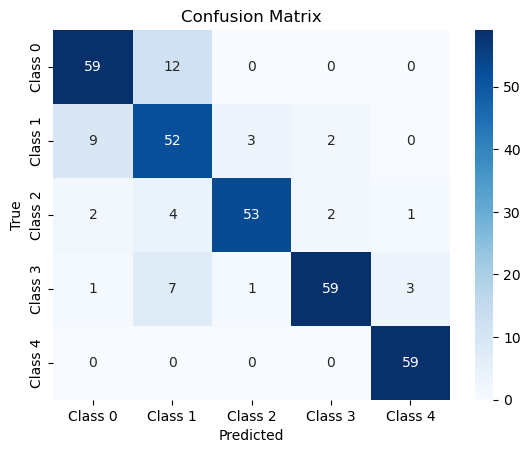

In [280]:
cm = confusion_matrix(y_test, y_pred_fin)
class_labels = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

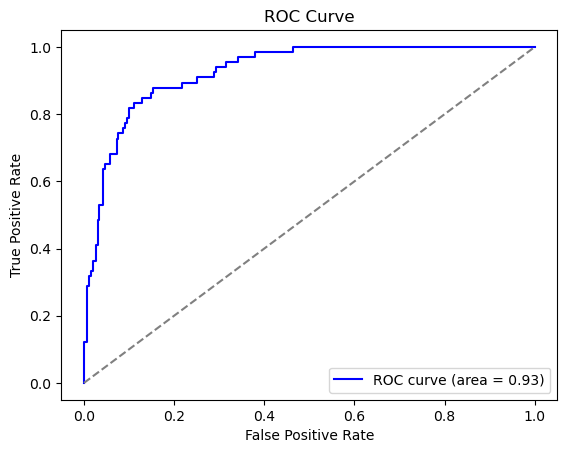

In [281]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt

lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
y_pred_prob = xgb_tuned.predict_proba(X_test)

fpr, tpr, _ = roc_curve(y_test_bin[:, 1], y_pred_prob[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

<a id='acc'></a>
### Accuracy Analysis

These results above only further emphasize that this model seems to be quite effective. We do see that it is least accurate when predicting class 1 (tends to overestimate the class), however since class 4 is the highest heart disease rating level of these classes we feel that this is actually beneficial. This is because it is better to poorly predict the lower classes, and tend towards overestimation of danger, in this application. Furthermore it is extremely effective at categorizing class 2 and 3, which are likely the most valuable areas to classify, because they are where the heart disease risk factors might not be as obvious, but critical to recognizing. 

**Scope and areas of improvement:**

We could see some improvement to this method by finding more globally demographically representative data. Right now all the datapoints come from only Europe and North America, however, if we hope for this model to be globally generalizable, we need to ensure that the model is not biased towards certain areas. This model does show promise however, given its high accuracy scores and thus we would hope that the ability of such a model to be used by doctors is priorized as a valid method. Furthermore, since doctors likely have so many patients and not enough time to run more extensive tests on all patients, this model is likely extremely valuable for triaging resources, and prioritizing the most vulnerable patients. 

Thank you that concludes our final project! We hope it showed that these predictive models can be very promising for doctors to rely on demographic and clinical risk factors in assessing heart disease.